In [1]:
##-------------------------------------------
## Libraries & Paths

suppressMessages(library(magrittr))
suppressMessages(library(dplyr))
suppressMessages(library(GSVA))
suppressMessages(library(GSEABase))
suppressMessages(library(org.Hs.eg.db))
suppressMessages(library(AnnotationDbi))
suppressMessages(library(limma))
suppressMessages(library(tidyverse))
suppressMessages(library(matrixStats))
suppressMessages(library(DESeq2))
suppressMessages(library(edgeR))
suppressMessages(library(tidyr))
suppressMessages(library(patchwork))
suppressMessages(library(tidytext))
suppressMessages(library(ComplexHeatmap))
suppressMessages(library(ggpubr))
suppressMessages(library(purrr))
source("/workdir/cjl332/cfrna_template/theme_ggplot_cfrna.R")
gene.list = read.delim("/workdir/cfrna/references/human/hg38/gencode.biotype.name.key.tsv")

Warning message:
“package ‘magrittr’ was built under R version 4.2.3”
Warning message:
“package ‘dplyr’ was built under R version 4.2.3”
Warning message:
“package ‘Biobase’ was built under R version 4.2.3”
Warning message:
“package ‘IRanges’ was built under R version 4.2.3”
Warning message:
“package ‘tibble’ was built under R version 4.2.3”
Warning message:
“package ‘tidyr’ was built under R version 4.2.3”
Warning message:
“package ‘purrr’ was built under R version 4.2.3”
Warning message:
“package ‘stringr’ was built under R version 4.2.3”
Warning message:
“package ‘forcats’ was built under R version 4.2.3”
Warning message:
“package ‘lubridate’ was built under R version 4.2.3”
Warning message:
“package ‘DESeq2’ was built under R version 4.2.3”
Warning message:
“package ‘GenomicRanges’ was built under R version 4.2.3”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.2.3”


In [2]:
# read in metadata
kdmiscmeta = read.csv("/workdir/adb258/ai_paper/data/cfrna_metadata-Radys.csv")
tbmeta = read.delim("/workdir/adb258/ai_paper/data/TB_metadata.tsv")
mecfsmeta = read.delim("/workdir/adb258/ai_paper/data/MECFS_preD1_metadata.tsv")

### Read in Long and Short Prompt Data

In [3]:
# Long Prompts

## ── KD ──────────────────────────────────────────────────────────────
KD_claude_old_long = read.csv("/workdir/adb258/ai_paper/data/long_prompts/KD_MISC_3.7Sonnet_long_200gene_100seed_array.csv") 
KD_claude_new_long = read.csv("/workdir/adb258/ai_paper/data/long_prompts/KD_MISC_Opus4_long_200gene_100seed_array.csv") 

KD_gemini_old_long = read.csv("/workdir/adb258/ai_paper/data/long_prompts/KD_MISC_geminiAdvanced2.0Flash_long_200gene_100seed_array.csv") 
KD_gemini_new_long = read.csv("/workdir/adb258/ai_paper/data/long_prompts/KD_MISC_gemini2.5Pro_long_200gene_100seed_array.csv") 

KD_gpt_old_long = read.csv("/workdir/adb258/ai_paper/data/long_prompts/KD_MISC_gpt4o_long_200gene_100seed_array.csv") 
KD_gpt_new_long = read.csv("/workdir/adb258/ai_paper/data/long_prompts/KD_MISC_gpto3_long_200gene_100seed_array.csv") 

## ── MECFS ──────────────────────────────────────────────────────────────
ME_claude_old_long  = read.csv("/workdir/adb258/ai_paper/data/long_prompts/MECFS_3.7Sonnet_long_200gene_100seed_array.csv")
ME_claude_new_long  = read.csv("/workdir/adb258/ai_paper/data/long_prompts/MECFS_Opus4_long_200gene_100seed_array.csv")

ME_gemini_old_long  = read.csv("/workdir/adb258/ai_paper/data/long_prompts/MECFS_geminiAdvanced2.0Flash_long_200gene_100seed_array.csv")
ME_gemini_new_long  = read.csv("/workdir/adb258/ai_paper/data/long_prompts/MECFS_gemini2.5Pro_long_200gene_100seed_array.csv")

ME_gpt_old_long     = read.csv("/workdir/adb258/ai_paper/data/long_prompts/MECFS_gpt4o_long_200gene_100seed_array.csv")
ME_gpt_new_long     = read.csv("/workdir/adb258/ai_paper/data/long_prompts/MECFS_gpto3_long_200gene_100seed_array.csv")


## ── TB ─────────────────────────────────────────────────────────────────
TB_claude_old_long  = read.csv("/workdir/adb258/ai_paper/data/long_prompts/TB_3.7Sonnet_long_200gene_100seed_array.csv")
TB_claude_new_long  = read.csv("/workdir/adb258/ai_paper/data/long_prompts/TB_Opus4_long_200gene_100seed_array.csv")

TB_gemini_old_long  = read.csv("/workdir/adb258/ai_paper/data/long_prompts/TB_geminiAdvanced2.0Flash_long_200gene_100seed_array.csv")
TB_gemini_new_long  = read.csv("/workdir/adb258/ai_paper/data/long_prompts/TB_gemini2.5Pro_long_200gene_100seed_array.csv")

TB_gpt_old_long     = read.csv("/workdir/adb258/ai_paper/data/long_prompts/TB_gpt4o_long_200gene_100seed_array.csv")
TB_gpt_new_long     = read.csv("/workdir/adb258/ai_paper/data/long_prompts/TB_gpto3_long_200gene_100seed_array.csv")


reference = read.csv("/workdir/adb258/ai_paper/data/TB_counts_gene_names.csv") 

In [4]:
# Short Prompts 

## ── KD ──────────────────────────────────────────────────────────────
KD_claude_old_short = read.csv("/workdir/adb258/ai_paper/data/short_prompts/KD_MISC_3.7Sonnet_short_200gene_100seed_array.csv") 
KD_claude_new_short = read.csv("/workdir/adb258/ai_paper/data/short_prompts/KD_MISC_Opus4_short_200gene_100seed_array.csv") 

KD_gemini_old_short = read.csv("/workdir/adb258/ai_paper/data/short_prompts/KD_MISC_geminiAdvanced2.0Flash_short_200gene_100seed_array.csv") 
KD_gemini_new_short = read.csv("/workdir/adb258/ai_paper/data/short_prompts/KD_MISC_gemini2.5Pro_short_200gene_100seed_array.csv") 

KD_gpt_old_short    = read.csv("/workdir/adb258/ai_paper/data/short_prompts/KD_MISC_gpt4o_short_200gene_100seed_array.csv") 
KD_gpt_new_short    = read.csv("/workdir/adb258/ai_paper/data/short_prompts/KD_MISC_gpto3_short_200gene_100seed_array.csv") 


## ── MECFS ──────────────────────────────────────────────────────────────
ME_claude_old_short = read.csv("/workdir/adb258/ai_paper/data/short_prompts/MECFS_3.7Sonnet_short_200gene_100seed_array.csv")
ME_claude_new_short = read.csv("/workdir/adb258/ai_paper/data/short_prompts/MECFS_Opus4_short_200gene_100seed_array.csv")

ME_gemini_old_short = read.csv("/workdir/adb258/ai_paper/data/short_prompts/MECFS_geminiAdvanced2.0Flash_short_200gene_100seed_array.csv")
ME_gemini_new_short = read.csv("/workdir/adb258/ai_paper/data/short_prompts/MECFS_gemini2.5Pro_short_200gene_100seed_array.csv")

ME_gpt_old_short    = read.csv("/workdir/adb258/ai_paper/data/short_prompts/MECFS_gpt4o_short_200gene_100seed_array.csv")
ME_gpt_new_short    = read.csv("/workdir/adb258/ai_paper/data/short_prompts/MECFS_gpto3_short_200gene_100seed_array.csv")


## ── TB ─────────────────────────────────────────────────────────────────
TB_claude_old_short = read.csv("/workdir/adb258/ai_paper/data/short_prompts/TB_3.7Sonnet_short_200gene_100seed_array.csv")
TB_claude_new_short = read.csv("/workdir/adb258/ai_paper/data/short_prompts/TB_Opus4_short_200gene_100seed_array.csv")

TB_gemini_old_short = read.csv("/workdir/adb258/ai_paper/data/short_prompts/TB_gemini2.0Flash_short_200gene_100seed_array.csv")
TB_gemini_new_short = read.csv("/workdir/adb258/ai_paper/data/short_prompts/TB_gemini2.5Pro_short_200gene_100seed_array.csv")

TB_gpt_old_short    = read.csv("/workdir/adb258/ai_paper/data/short_prompts/TB_gpt4o_short_200gene_100seed_array.csv")
TB_gpt_new_short    = read.csv("/workdir/adb258/ai_paper/data/short_prompts/TB_gpto3_short_200gene_100seed_array.csv")

In [9]:
library(tibble)
library(dplyr)

## ── 0.  Make a named list that points to every long-prompt data frame ─────
##      (Adjust labels if you prefer other wording.)
datasets_long <- list(
  # KD / MIS-C  ──────────────────────────────────────────────────────────
  "ChatGPT 4o (KD)"        = KD_gpt_old_long,        # gpt4o
  "ChatGPT o3 (KD)"        = KD_gpt_new_long,        # gpto3
  "Claude 3.7 Sonnet (KD)"     = KD_claude_old_long,     # 3.7 Sonnet
  "Claude Opus4 (KD)"     = KD_claude_new_long,     # Opus-4
  "Gemini 2.5 Pro (KD)"    = KD_gemini_new_long,     # 2.5 Pro
  "Gemini 2.0 Flash (KD)"  = KD_gemini_old_long,     # Advanced Flash 2.0
  
  # TB  ──────────────────────────────────────────────────────────────────
  "ChatGPT 4o (TB)"        = TB_gpt_old_long,
  "ChatGPT o3 (TB)"        = TB_gpt_new_long,
  "Claude 3.7 Sonnet (TB)"     = TB_claude_old_long,
  "Claude Opus4 (TB)"     = TB_claude_new_long,
  "Gemini 2.5 Pro (TB)"    = TB_gemini_new_long,
  "Gemini 2.0 Flash (TB)"  = TB_gemini_old_long,
  
  # ME/CFS  ──────────────────────────────────────────────────────────────
  "ChatGPT 4o (ME/CFS)"        = ME_gpt_old_long,
  "ChatGPT o3 (ME/CFS)"        = ME_gpt_new_long,
  "Claude 3.7 Sonnet (ME/CFS)"     = ME_claude_old_long,
  "Claude Opus4 (ME/CFS)"     = ME_claude_new_long,
  "Gemini 2.5 Pro (ME/CFS)"    = ME_gemini_new_long,
  "Gemini 2.0 Flash (ME/CFS)"  = ME_gemini_old_long
)

## ── 1.  Helper: count rows ≠ NA and compute deviation ─────────────────────
get_seed_deviation <- function(df, model_with_condition) {
  ## Expect labels like "ChatGPT o3 (KD)"  or  "Claude Opus-4 (ME/CFS)"
  m <- regexec("^(.*?)\\s*\\((.*?)\\)$", model_with_condition)
  parts <- regmatches(model_with_condition, m)[[1]]
  
  model_raw <- trimws(parts[2])            # "ChatGPT o3"
  cond_raw  <- trimws(parts[3])            # "KD" / "TB" / "ME/CFS"
  
  # Normalise the condition wording used in earlier scripts
  condition <- dplyr::recode(cond_raw,
    "KD"      = "KD/MIS-C",
    "MISC"    = "KD/MIS-C",
    "MIS-C"   = "KD/MIS-C",
    "ME/CFS"  = "ME/CFS",
    "MECFS"   = "ME/CFS",
    .default  = cond_raw      # TB stays TB, etc.
  )
  
  tibble(
    Seed       = colnames(df),
    FilledRows = colSums(df != "" & !is.na(df)),
    Deviation  = FilledRows - 200,
    Model      = model_raw,
    Condition  = condition
  )
}

## ── 2.  Build the tidy deviation table for *all* 18 data frames ───────────
deviation_tbl <- bind_rows(
  Map(get_seed_deviation, datasets_long, names(datasets_long))
) |>
  mutate(
    Grp = paste(Model, Condition, sep = " — "),
    # put KD/MIS-C first, then TB, then ME/CFS, each block ordered by model name
    Grp = factor(
      Grp,
      levels = c(                             # KD / MIS-C
        "ChatGPT 4o — KD/MIS-C", "ChatGPT o3 — KD/MIS-C",
        "Claude 3.7 Sonnet — KD/MIS-C", "Claude Opus4 — KD/MIS-C",
        "Gemini 2.5 Pro — KD/MIS-C", "Gemini 2.0 Flash — KD/MIS-C",
        # TB
        "ChatGPT 4o — TB", "ChatGPT o3 — TB",
        "Claude 3.7 Sonnet — TB", "Claude Opus4 — TB",
        "Gemini 2.5 Pro — TB", "Gemini 2.0 Flash — TB",
        # ME/CFS
        "ChatGPT 4o — ME/CFS", "ChatGPT o3 — ME/CFS",
        "Claude 3.7 Sonnet — ME/CFS", "Claude Opus4 — ME/CFS",
        "Gemini 2.5 Pro — ME/CFS", "Gemini 2.0 Flash — ME/CFS"
      )
    )
  )

In [10]:
deviation_tbl %>%
  group_by(Model) %>%
  summarise(mean_abs_deviation = mean(abs(Deviation), na.rm = TRUE))

Model,mean_abs_deviation
<chr>,<dbl>
ChatGPT 4o,58.570000
ChatGPT o3,2.096667
Claude 3.7 Sonnet,3.056667
Claude Opus4,4.223333
Gemini 2.0 Flash,63.496667
Gemini 2.5 Pro,37.200000


In [8]:
deviation_tbl %>%                               
  filter(Model %in% c(  
  "ChatGPT 4o",     
  "ChatGPT o3 (KD)",       
  "Claude 3.7 Sonnet (KD)",  
  "Claude Opus4 (KD)",    
  "Gemini 2.5 Pro (KD)",  
  "Gemini Flash 2.0 (KD)")) %>% 
  group_by(Model) %>% 
  summarise(max_deviation = max(Deviation, na.rm = TRUE))

Model,max_deviation
<chr>,<dbl>
ChatGPT 4o,283


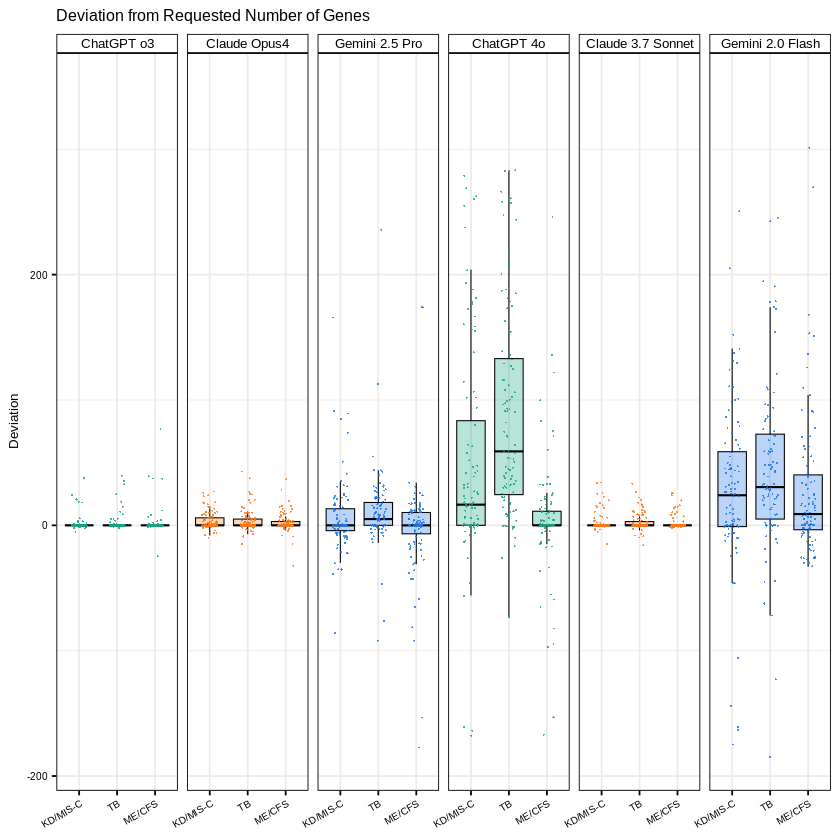

In [12]:
## ------------------------------------------------------------------
## 0.  Declare the facet order once per session
##     (new models first, then old)
## ------------------------------------------------------------------
model_order <- c("ChatGPT o3",
                 "Claude Opus4",
                 "Gemini 2.5 Pro",
                 "ChatGPT 4o",
                 "Claude 3.7 Sonnet",
                 "Gemini 2.0 Flash")



# single colour per vendor, reused for both versions
base_cols <- c(
  "ChatGPT o3"                = "#10a37f",
  "ChatGPT 4o"                = "#10a37f",   # same teal
  "Claude Opus4"              = "#ff7613",
  "Claude 3.7 Sonnet"             = "#ff7613",   # same orange
  "Gemini 2.5 Pro"            = "#1a73e8",
  "Gemini 2.0 Flash" = "#1a73e8"    # same blue
)

plot_tbl <- deviation_tbl %>%
  filter(Model %in% model_order) %>%
  mutate(
    Model     = factor(Model, levels = model_order),
    Condition = factor(Condition, levels = c("KD/MIS-C", "TB", "ME/CFS"))
  )

#pdf("/workdir/adb258/ai_paper/figures/length_deviation.pdf", width = 7, height = 2) 

ggplot(plot_tbl, aes(x = Condition, y = Deviation)) +
  geom_boxplot(aes(fill = Model),
               colour = "black", outlier.shape = NA, lwd = .3) +
  geom_jitter(aes(color = Model),
              width = .2, size = .25, alpha = .8, shape = 16) +
  facet_grid(~ Model, scales = "free_x", space = "free_x") +
  coord_cartesian(ylim = c(min(plot_tbl$Deviation), 350)) +
  scale_fill_manual(values = scales::alpha(base_cols, 0.30), guide = "none") +
  scale_color_manual(values = base_cols,                     guide = "none") +
  labs(x = NULL,
       y = "Deviation",
       title = "Deviation from Requested Number of Genes") +
  theme_cfrna_print() +
  theme(
    strip.text  = element_text(size = 8,
                               margin = margin(t = 2, r = 4, b = 2, l = 4)),
    axis.text.x = element_text(angle = 30, hjust = 1)
  )

#dev.off()

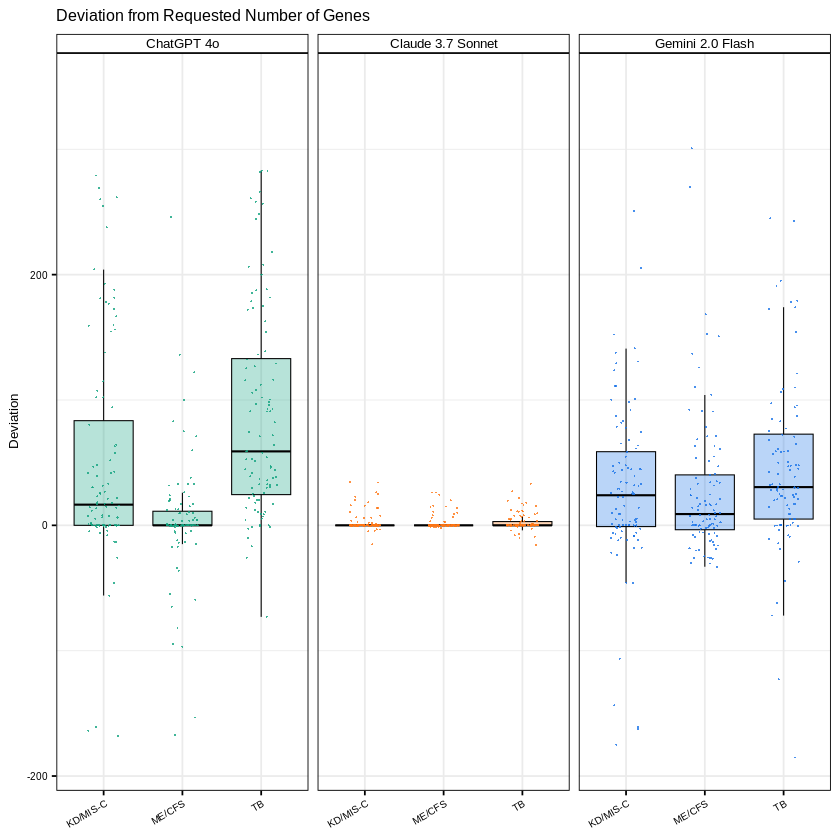

In [13]:
wanted_models <- c("ChatGPT 4o", "Claude 3.7 Sonnet", "Gemini 2.0 Flash")

base_cols <- c("ChatGPT 4o"     = "#10a37f",
               "Claude 3.7 Sonnet"  = "#ff7613",
               "Gemini 2.0 Flash" = "#1a73e8")

#pdf("/workdir/adb258/ai_paper/figures/length_deviation_old.pdf", width = 3.5, height = 2)

ggplot(
  deviation_tbl |> filter(Model %in% wanted_models),
  aes(x = Condition, y = Deviation)
) +
  geom_boxplot(aes(fill = Model),
               colour = "black",
               outlier.shape = NA, lwd = .3) +
  geom_jitter(aes(color = Model),
              width = .2, size = .25, alpha = 0.8, shape = 16) +
  facet_grid(~ Model, scales = "free_x", space = "free_x") +
  coord_cartesian(ylim = c(min(deviation_tbl$Deviation), 350)) +
  scale_fill_manual(values = alpha(base_cols[wanted_models], 0.30), guide = "none") +
  scale_color_manual(values = base_cols[wanted_models],              guide = "none") +
  scale_x_discrete(labels = c("KD/MIS-C" = "KD/MIS-C")) +
  labs(
    x     = NULL,
    y     = "Deviation",
    title = "Deviation from Requested Number of Genes"
  ) +
  theme_cfrna_print() +
  theme(
    strip.text  = element_text(size = 8,
                               margin = margin(t = 2, r = 4, b = 2, l = 4)),
    axis.text.x = element_text(angle = 30, hjust = 1)
  )

#dev.off()

### Long vs short comp - length

In [14]:
# ---------------------------------------------------------------------------
# 0.  Models we want in the plot / stats
# ---------------------------------------------------------------------------
new_models <- c("ChatGPT o3", "Claude Opus4", "Gemini 2.5 Pro")

# ---------------------------------------------------------------------------
# 1.  Helper  (robust to 1‑column frames or vectors)
# ---------------------------------------------------------------------------
get_seed_deviation <- function(raw_df, model_with_condition, prompt_len) {

  ## Always coerce to a plain data‑frame
  df <- as.data.frame(raw_df)

  # If the file came in with row names and *one* unnamed column, give it a name
  if (is.null(colnames(df))) {
    colnames(df) <- "Seed1"
  }

  filled <- vapply(df, function(col) sum(!is.na(col) & col != ""), integer(1))

  m <- regexec("^(.*?)\\s*\\((.*?)\\)$", model_with_condition)
  parts <- regmatches(model_with_condition, m)[[1]]

  model_raw <- trimws(parts[2])
  cond_raw  <- trimws(parts[3])

  condition <- recode(cond_raw,
                      "KD"     = "KD/MIS-C",
                      "MISC"   = "KD/MIS-C",
                      "MIS-C"  = "KD/MIS-C",
                      "MECFS"  = "ME/CFS",
                      .default = cond_raw)

  tibble(
    Seed         = names(filled),
    FilledRows   = filled,
    Deviation    = FilledRows - 200,
    Model        = model_raw,
    Condition    = condition,
    PromptLength = prompt_len
  )
}

# ---------------------------------------------------------------------------
# 2.  Build LONG + SHORT tables, then filter to new models
# ---------------------------------------------------------------------------
dev_long <- bind_rows(
  imap(datasets_long, ~ get_seed_deviation(.x, .y, "Long"))
) %>% filter(Model %in% new_models)

dev_short <- bind_rows(
  imap(datasets_short, ~ get_seed_deviation(.x, .y, "Short"))
) %>% filter(Model %in% new_models)

deviation_all <- bind_rows(dev_long, dev_short) %>%
  mutate(
    Model        = factor(Model,     levels = new_models),
    Condition    = factor(Condition, levels = c("KD/MIS-C", "TB", "ME/CFS")),
    PromptLength = factor(PromptLength, levels = c("Long", "Short"))
  )

ERROR: Error in vctrs_vec_compat(.x, .purrr_user_env): object 'datasets_short' not found


In [150]:
write.csv(deviation_all, "/workdir/adb258/ai_paper/data/deviation_length_all.csv")

In [20]:
# ──────────────────────────────────────────────────────────────────
# 1.  Build a compound x‑axis factor  (Condition · PromptLength)
# ──────────────────────────────────────────────────────────────────
deviation_all <- deviation_all %>%
  mutate(
    CondPrompt = factor(
      paste(Condition, PromptLength, sep = " · "),
      levels = c(
        "KD/MIS-C · Long",  "KD/MIS-C · Short",
        "TB · Long",        "TB · Short",
        "ME/CFS · Long",    "ME/CFS · Short"
      )
    )
  )

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Deviation from Requested Number of Genes – Long vs Short Prompt' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Deviation from Requested Number of Genes – Long vs Short Prompt' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Deviation from Requested Number of Genes – Long vs Short Prompt' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Deviation from Requested Number of Genes – Long vs Short Prompt' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Deviation from Requested Number 

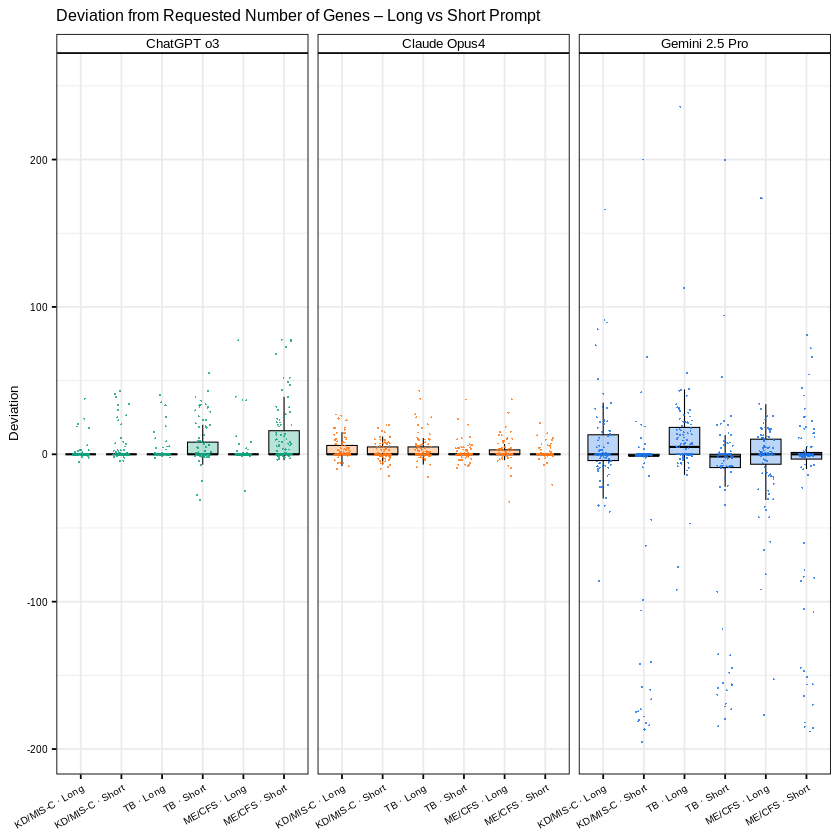

In [30]:
#pdf("/workdir/adb258/ai_paper/figures/length_deviation_short_vs_long.pdf", width = 5, height = 2.5)

ggplot(deviation_all, aes(x = CondPrompt, y = Deviation)) +
  geom_boxplot(aes(fill = Model),
               colour = "black", outlier.shape = NA, lwd = .3, alpha = 0.30) +
  geom_jitter(aes(colour = Model),
              width = .2, size = .25, alpha = .8, shape = 16) +
  facet_grid(~ Model, scales = "free_x", space = "free_x") +
  coord_cartesian(ylim = c(min(deviation_all$Deviation), 250)) +
  scale_fill_manual(values = scales::alpha(base_cols, 0.30), guide = "none") +
  scale_colour_manual(values = base_cols,                     guide = "none") +
  labs(
    x = NULL,
    y = "Deviation",
    title = "Deviation from Requested Number of Genes – Long vs Short Prompt"
  ) +
  theme_cfrna_print() +
  theme(
    strip.text  = element_text(size = 8,
                               margin = margin(t = 2, r = 4, b = 2, l = 4)),
    axis.text.x = element_text(angle = 30, hjust = 1)
  )

#dev.off()

In [33]:
# ---------------------------------------------------------------------------
# 4.  Paired t‑tests: Short vs Long within Model × Condition
# ---------------------------------------------------------------------------
pval_tbl <- deviation_all %>%
  dplyr::select(Model, Condition, PromptLength, Seed, Deviation) %>%
  pivot_wider(names_from = PromptLength, values_from = Deviation) %>%
  group_by(Model, Condition) %>%
  summarise(tidy = list(broom::tidy(t.test(Short, Long, paired = TRUE))),
            .groups = "drop") %>%
  unnest(tidy) %>%
  dplyr::select(Model, Condition,
         t = statistic,
         p = p.value) %>%
  group_by(Condition) %>%   # adjust within condition block
  mutate(
    p_adj_BH   = p.adjust(p, method = "BH"),
    p_adj_bonf = p.adjust(p, method = "bonferroni")
  ) %>%
  ungroup() %>%
  arrange(Condition, Model)

write.csv(pval_tbl, "/workdir/adb258/ai_paper/data/shortvslong_length_stats.csv")

### Invalid Genes

In [152]:
# reference is either a 1‑column data frame or a plain vector
get_offlist_pct <- function(df, model, condition, ref_vec) {

  out <- lapply(colnames(df), function(seed) {

    this_col <- df[[seed]]

    # mask of cells that actually contain a gene name
    keep     <- this_col != "" & !is.na(this_col)

    Filled   <- sum(keep)                               # total genes returned
    OffList  <- sum(keep & !(this_col %in% ref_vec))     # counter you asked for

    tibble(
      Seed     = seed,
      OffList  = OffList,
      Filled   = Filled,
      OffPct   = ifelse(Filled == 0, NA_real_, 100 * OffList / Filled)
    )
  }) |>
    bind_rows() |>
    mutate(Model = model,
           Condition = condition)
}

## ── 1.  Tiny helper to pull “Model” and “Condition” out of the list name ──
parse_label <- function(lbl) {
  m      <- regexec("^(.*?)\\s*\\((.*?)\\)$", lbl)
  parts  <- regmatches(lbl, m)[[1]][-1]        # drop full match
  model  <- trimws(parts[1])                   # "ChatGPT o3"
  cond   <- trimws(parts[2])                   # "KD", "TB", "ME/CFS", …
  
  condition <- recode(cond,
                      "KD"    = "KD/MIS-C",
                      "MIS-C" = "KD/MIS-C",
                      "MISC"  = "KD/MIS-C",
                      "MECFS" = "ME/CFS",
                      .default = cond)
  list(model = model, condition = condition)
}

## ── 2.  Build `bad_pct_tbl` in one pass  ──────────────────────────────────
ref_genes <- reference[[1]]   # take the single column as a vector

bad_pct_tbl <- imap_dfr(datasets_long, function(df, lbl) {
  info <- parse_label(lbl)
  get_offlist_pct(df, info$model, info$condition, ref_genes)
})

In [153]:
bad_pct_tbl %>%
  group_by(Model) %>%
  summarise(
    mean_offlist_pct  = mean(OffPct, na.rm = TRUE),
    min_offlist_pct   = min(OffPct,  na.rm = TRUE),
    max_offlist_pct   = max(OffPct,  na.rm = TRUE),
    range_offlist_pct = max_offlist_pct - min_offlist_pct
  )

Model,mean_offlist_pct,min_offlist_pct,max_offlist_pct,range_offlist_pct
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ChatGPT 4o,29.974058,0,93.86792,93.86792
ChatGPT o3,2.428696,0,9.50000,9.50000
Claude 3.7 Sonnet,1.299986,0,21.84466,21.84466
Claude Opus4,4.353755,0,21.07843,21.07843
Gemini 2.0 Flash,19.182249,0,87.40157,87.40157
Gemini 2.5 Pro,2.575908,0,24.74227,24.74227


In [154]:
head(bad_pct_tbl)

Seed,OffList,Filled,OffPct,Model,Condition
<chr>,<int>,<int>,<dbl>,<chr>,<chr>
seed_1_all,20,195,10.25641,ChatGPT 4o,KD/MIS-C
seed_2_all,105,206,50.97087,ChatGPT 4o,KD/MIS-C
seed_3_all,188,382,49.21466,ChatGPT 4o,KD/MIS-C
seed_4_all,87,144,60.41667,ChatGPT 4o,KD/MIS-C
seed_5_all,0,200,0.00000,ChatGPT 4o,KD/MIS-C
seed_6_all,0,200,0.00000,ChatGPT 4o,KD/MIS-C


In [62]:
## ---------- 1.  Facet and colour metadata -------------------------------
model_order <- c("ChatGPT o3",
                 "Claude Opus4",
                 "Gemini 2.5 Pro",
                 "ChatGPT 4o",
                 "Claude 3.7 Sonnet",
                 "Gemini 2.0 Flash")

base_cols <- c(
  "ChatGPT o3"                = "#10a37f",
  "ChatGPT 4o"                = "#10a37f",   # same teal
  "Claude Opus4"              = "#ff7613",
  "Claude 3.7 Sonnet"             = "#ff7613",   # same orange
  "Gemini 2.5 Pro"            = "#1a73e8",
  "Gemini 2.0 Flash" = "#1a73e8"    # same blue
)

cond_order <- c("KD/MIS-C", "TB", "ME/CFS")

## ---------- 2.  Prep the plotting tibble -------------------------------
plot_tbl <- bad_pct_tbl %>%
  dplyr::filter(Model %in% model_order) %>%
  dplyr::mutate(
    Model     = factor(Model,     levels = model_order),
    Condition = factor(Condition, levels = cond_order)
  )

## ---------- 3.  Plot -----------------------------------------------------
pdf("/workdir/adb258/ai_paper/figures/invalid_pct_all.pdf", width = 7, height = 2) 

ggplot(plot_tbl, aes(x = Condition, y = OffPct)) +
  geom_boxplot(aes(fill = Model),
               colour = "black", outlier.shape = NA, lwd = .3) +
  geom_jitter(aes(color = Model),
              width = .2, size = .25, alpha = .8, shape = 16) +
  facet_grid(~ Model, scales = "free_x", space = "free_x") +
  coord_cartesian(ylim = c(0, 100)) +
  scale_fill_manual(values = scales::alpha(base_cols, 0.30), guide = "none") +
  scale_color_manual(values = base_cols,                     guide = "none") +
  labs(x = NULL,
       y = "Percent",
       title = "Percent of Reported Genes Outside Reference") +
  theme_cfrna_print() +
  theme(
    strip.text  = element_text(size = 8,
                               margin = margin(t = 2, r = 4, b = 2, l = 4)),
    axis.text.x = element_text(angle = 30, hjust = 1)
  ) +
  scale_x_discrete(labels = c("KD/MIS-C" = "KD/MIS-C"))

dev.off()

pdf 
  2

### Short vs long invalid gene percentage

In [155]:
# ────────────────────────────────────────────────────────────────────────
# 0.  “New” models, colour palette, reference gene list
# ────────────────────────────────────────────────────────────────────────
new_models <- c("ChatGPT o3", "Claude Opus4", "Gemini 2.5 Pro")

base_cols <- c(
  "ChatGPT o3"     = "#10a37f",
  "Claude Opus4"   = "#ff7613",
  "Gemini 2.5 Pro" = "#1a73e8"
)

ref_genes <- reference[[1]]                       # vector of reference genes

# ────────────────────────────────────────────────────────────────────────
# 1.  Lists of LONG and SHORT data frames (only new models)
#     – names follow “Model (Condition)” pattern
# ────────────────────────────────────────────────────────────────────────
datasets_long_new <- list(
  "ChatGPT o3 (KD)"       = KD_gpt_new_long,
  "Claude Opus4 (KD)"     = KD_claude_new_long,
  "Gemini 2.5 Pro (KD)"   = KD_gemini_new_long,
  "ChatGPT o3 (TB)"       = TB_gpt_new_long,
  "Claude Opus4 (TB)"     = TB_claude_new_long,
  "Gemini 2.5 Pro (TB)"   = TB_gemini_new_long,
  "ChatGPT o3 (ME/CFS)"   = ME_gpt_new_long,
  "Claude Opus4 (ME/CFS)" = ME_claude_new_long,
  "Gemini 2.5 Pro (ME/CFS)" = ME_gemini_new_long
)

datasets_short_new <- list(
  "ChatGPT o3 (KD)"       = KD_gpt_new_short,
  "Claude Opus4 (KD)"     = KD_claude_new_short,
  "Gemini 2.5 Pro (KD)"   = KD_gemini_new_short,
  "ChatGPT o3 (TB)"       = TB_gpt_new_short,
  "Claude Opus4 (TB)"     = TB_claude_new_short,
  "Gemini 2.5 Pro (TB)"   = TB_gemini_new_short,
  "ChatGPT o3 (ME/CFS)"   = ME_gpt_new_short,
  "Claude Opus4 (ME/CFS)" = ME_claude_new_short,
  "Gemini 2.5 Pro (ME/CFS)" = ME_gemini_new_short
)

# ────────────────────────────────────────────────────────────────────────
# 2.  Helpers
# ────────────────────────────────────────────────────────────────────────
parse_label <- function(lbl) {
  m      <- regexec("^(.*?)\\s*\\((.*?)\\)$", lbl)
  parts  <- regmatches(lbl, m)[[1]][-1]
  model  <- trimws(parts[1])
  cond   <- trimws(parts[2])
  list(
    model      = model,
    condition  = recode(cond,
                        "KD"    = "KD/MIS-C",
                        "MIS-C" = "KD/MIS-C",
                        "MISC"  = "KD/MIS-C",
                        "MECFS" = "ME/CFS",
                        .default = cond)
  )
}

get_offlist_pct <- function(raw_df, model, condition, prompt_len, ref_vec) {
  df <- as.data.frame(raw_df)
  if (is.null(colnames(df))) colnames(df) <- paste0("Seed", seq_len(ncol(df)))

  bind_rows(lapply(colnames(df), function(seed) {
    col   <- df[[seed]]
    keep  <- col != "" & !is.na(col)
    tibble(
      Seed      = seed,
      OffList   = sum(keep & !(col %in% ref_vec)),
      Filled    = sum(keep),
      OffPct    = ifelse(Filled == 0, NA_real_, 100 * OffList / Filled)
    )
  })) %>%
    mutate(
      Model        = model,
      Condition    = condition,
      PromptLength = prompt_len
    )
}

# ────────────────────────────────────────────────────────────────────────
# 3.  Build tidy table for LONG & SHORT
# ────────────────────────────────────────────────────────────────────────
off_long <- imap_dfr(datasets_long_new, function(df, lbl) {
  info <- parse_label(lbl)
  get_offlist_pct(df, info$model, info$condition, "Long", ref_genes)
})

off_short <- imap_dfr(datasets_short_new, function(df, lbl) {
  info <- parse_label(lbl)
  get_offlist_pct(df, info$model, info$condition, "Short", ref_genes)
})

off_all <- bind_rows(off_long, off_short) %>%
  filter(Model %in% new_models) %>%
  mutate(
    Model        = factor(Model, levels = new_models),
    Condition    = factor(Condition, levels = c("KD/MIS-C", "TB", "ME/CFS")),
    PromptLength = factor(PromptLength, levels = c("Long", "Short")),
    CondPrompt   = factor(
      paste(Condition, PromptLength, sep = " · "),
      levels = c("KD/MIS-C · Long", "KD/MIS-C · Short",
                 "TB · Long",       "TB · Short",
                 "ME/CFS · Long",   "ME/CFS · Short")
    )
  )

In [157]:
write.csv(off_all, "/workdir/adb258/ai_paper/data/badgenes_data_all.csv")

In [38]:
# ────────────────────────────────────────────────────────────────────────
# 4.  Plot  (same aesthetics)
# ────────────────────────────────────────────────────────────────────────
pairs_ls <- list(
  c("KD/MIS-C · Long", "KD/MIS-C · Short"),
  c("TB · Long",       "TB · Short"),
  c("ME/CFS · Long",   "ME/CFS · Short")
)

pdf("/workdir/adb258/ai_paper/figures/offlist_pct_short_vs_long.pdf", width = 5, height = 2.5)

ggplot(off_all, aes(x = CondPrompt, y = OffPct)) +
  geom_boxplot(aes(fill = Model),
               colour = "black", outlier.shape = NA, lwd = .3, alpha = 0.30) +
  geom_jitter(aes(colour = Model),
              width = .2, size = .25, alpha = .8, shape = 16) +
  facet_grid(~ Model, scales = "free_x", space = "free_x") +
  coord_cartesian(ylim = c(0, 100)) +
  scale_fill_manual(values = scales::alpha(base_cols, 0.30), guide = "none") +
  scale_colour_manual(values = base_cols,                     guide = "none") +
  labs(
    x = NULL,
    y = "Percent",
    title = "Percent of Reported Genes Outside Reference – Long vs Short Prompt"
  ) +
  theme_cfrna_print() +
  theme(
    strip.text  = element_text(size = 8,
                               margin = margin(t = 2, r = 4, b = 2, l = 4)),
    axis.text.x = element_text(angle = 30, hjust = 1)
  )

dev.off()

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Percent of Reported Genes Outside Reference – Long vs Short Prompt' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Percent of Reported Genes Outside Reference – Long vs Short Prompt' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Percent of Reported Genes Outside Reference – Long vs Short Prompt' in 'mbcsToSbcs': dot substituted for <93>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Percent of Reported Genes Outside Reference – Long vs Short Prompt' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Percent of Reported 

pdf 
  2

In [42]:
# ────────────────────────────────────────────────────────────────────────
# 5.  Paired t‑test table  (Short vs Long, per Model × Condition)
# ────────────────────────────────────────────────────────────────────────
pval_off_tbl <- off_all %>%
  dplyr::select(Model, Condition, PromptLength, Seed, OffPct) %>%
  pivot_wider(names_from = PromptLength, values_from = OffPct) %>%
  group_by(Model, Condition) %>%
  summarise(tidy = list(broom::tidy(t.test(Short, Long, paired = TRUE))),
            .groups = "drop") %>%
  unnest(tidy) %>%
  dplyr::select(Model, Condition,
         t = statistic,
         p = p.value) %>%
  group_by(Condition) %>%
  mutate(
    p_adj_BH   = p.adjust(p, method = "BH"),
    p_adj_bonf = p.adjust(p, method = "bonferroni")
  ) %>%
  ungroup() %>%
  arrange(Condition, Model)

print(pval_off_tbl)
write.csv(pval_off_tbl, "/workdir/adb258/ai_paper/data/OffListPct_Short_vs_Long_pvals.csv", row.names = FALSE)

# A tibble: 9 × 6
  Model          Condition      t      p p_adj_BH p_adj_bonf
  <fct>          <fct>      <dbl>  <dbl>    <dbl>      <dbl>
1 ChatGPT o3     KD/MIS-C   1.66  0.101    0.151      0.302 
2 Claude Opus4   KD/MIS-C   1.79  0.0760   0.151      0.228 
3 Gemini 2.5 Pro KD/MIS-C   1.14  0.256    0.256      0.768 
4 ChatGPT o3     TB        -2.04  0.0436   0.0654     0.131 
5 Claude Opus4   TB        -0.154 0.878    0.878      1     
6 Gemini 2.5 Pro TB         2.34  0.0214   0.0641     0.0641
7 ChatGPT o3     ME/CFS     0.442 0.660    0.660      1     
8 Claude Opus4   ME/CFS    -1.33  0.185    0.278      0.556 
9 Gemini 2.5 Pro ME/CFS     1.97  0.0520   0.156      0.156 


### Calculate Duplicate Percentage

In [288]:
get_dup_pct <- function(df, model, condition) {

  out <- lapply(colnames(df), function(seed) {

    genes <- df[[seed]][df[[seed]] != "" & !is.na(df[[seed]])]   # non‑empty cells
    n_tot <- length(genes)

    n_dup <- n_tot - length(unique(genes))   # duplicates = total − uniques
    pct   <- ifelse(n_tot == 0, NA_real_, 100 * n_dup / n_tot)

    tibble(Seed = seed,
           DupPct = pct)
  }) |>
    bind_rows() |>
    mutate(Model = model,
           Condition = condition)
}

dup_tbl <- bind_rows(
  get_dup_pct(KD_gpt,      "ChatGPT", "KD/MIS‑C"),
  get_dup_pct(TB_gpt,      "ChatGPT", "TB"),
  get_dup_pct(ME_gpt,   "ChatGPT", "MECFS"),
  get_dup_pct(KD_gemini,   "Gemini",  "KD/MIS‑C"),
  get_dup_pct(TB_gemini,   "Gemini",  "TB"),
  get_dup_pct(ME_gemini,"Gemini",  "MECFS"),
  get_dup_pct(KD_claude,   "Claude",  "KD/MIS‑C"),
  get_dup_pct(TB_claude,   "Claude",  "TB"),
  get_dup_pct(ME_claude,"Claude",  "MECFS")
)

In [289]:
dup_tbl %>%
  group_by(Model) %>%
  summarise(
    mean_dup_pct  = mean(DupPct, na.rm = TRUE)
  )

Model,mean_dup_pct
<chr>,<dbl>
ChatGPT,5.7268147
Claude,0.1276535
Gemini,3.4144544


In [9]:
pdf("/workdir/adb258/ai_paper/figures/duplicate_pct.pdf", width = 3.5, height = 2)

ggplot(dup_tbl, aes(x = Condition, y = DupPct)) +
  geom_boxplot(aes(fill = Model),
               colour = "black", lwd = .3,
               outlier.shape = NA) +
  geom_jitter(aes(color = Model),
              width = .2, size = .25, alpha = .8, shape = 16) +

  facet_grid(~ Model, scales = "free_x", space = "free_x") +
  coord_cartesian(ylim = c(0, 100)) +

  scale_fill_manual(values = fill_cols, guide = "none") +
  scale_color_manual(values = cols,      guide = "none") +
  labs(x = NULL,
       y = "Percent",
       title = "Percent of Duplicate Genes Reported") +
  theme_cfrna_print() +
  theme(strip.text = element_text(size = 8,
                                  margin = margin(t = 2, r = 4, b = 2, l = 4)),
        axis.text.x = element_text(angle = 30, hjust = 1))

dev.off()

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'KD/MIS‑C' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'KD/MIS‑C' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'KD/MIS‑C' in 'mbcsToSbcs': dot substituted for <91>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'KD/MIS‑C' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'KD/MIS‑C' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'KD/MIS‑C' in 'mbcsToSbcs': dot substituted for <91>”
Warning message in grid.Call(C_textBounds, as.

pdf 
  2

## Gene Frequency

In [15]:
##############################################################################
## Load every *_prerankedInput.csv file and create objects named:
##   count_<COND>_<MODEL>_<PROMPT>
## where:
##   COND   = KD | TB | ME
##   MODEL  = gpt4o , 3.7Sonnet , gemini2.5Pro … (whatever follows the condition)
##   PROMPT = long | short
##
## Each resulting data-frame has:
##   • rownames      = text before the first space
##   • "score" col   = text after  the first space
##############################################################################

library(stringr)   # only used for startsWith equivalent; base R is fine

data_dir  <- "/workdir/adb258/ai_paper/data/GSEA_prerankedInputFiles"
csv_files <- list.files(data_dir,
                        pattern = "_prerankedInput\\.csv$",
                        full.names = TRUE)

if (!length(csv_files))
  stop("No *_prerankedInput.csv files found in ", data_dir)

# ---------- helper: identify condition & strip prefix -----------------------
get_condition <- function(fname) {
  if (startsWith(fname, "KD_MISC_"))  list(cond = "KD", rest = sub("^KD_MISC_",  "", fname))
  else if (startsWith(fname, "MECFS_")) list(cond = "ME", rest = sub("^MECFS_",   "", fname))
  else if (startsWith(fname, "TB_"))    list(cond = "TB", rest = sub("^TB_",      "", fname))
  else                                  NULL   # unknown condition → skip
}

# --------------------- main loop --------------------------------------------
for (f in csv_files) {

  base <- basename(f)
  info <- get_condition(base)

  if (is.null(info)) {
    warning("Skipping unrecognised condition in filename: ", base)
    next
  }

  # Strip extension, then split on underscores to grab MODEL and PROMPT
  sans_csv <- sub("\\.csv$", "", info$rest)
  parts    <- strsplit(sans_csv, "_", fixed = TRUE)[[1]]

  if (length(parts) < 2) {
    warning("Filename too short to parse model/prompt: ", base)
    next
  }

  model  <- parts[1]            # e.g. gpt4o, 3.7Sonnet, gemini2.5Pro
  prompt <- parts[2]            # long / short

  obj_name <- paste0("count_", info$cond, "_", model, "_", prompt)

  # ------------ read with whitespace separator -----------------------------
  df <- read.table(f,
                   header            = FALSE,
                   sep               = "",      # any whitespace
                   row.names         = 1,
                   stringsAsFactors  = FALSE,
                   comment.char      = "",      # ignore no lines
                   quote             = "")      # treat quotes as regular chars

  colnames(df) <- "freq"        # give the single column a useful name

  assign(obj_name, df, envir = .GlobalEnv)
}

# Quick sanity check: what did we just create?
ls(pattern = "^count_")

[1] "count_KD_3.7Sonnet_long"              
 [2] "count_KD_3.7Sonnet_short"             
 [3] "count_KD_gemini2.5Pro_long"           
 [4] "count_KD_gemini2.5Pro_short"          
 [5] "count_KD_geminiAdvanced2.0Flash_long" 
 [6] "count_KD_geminiAdvanced2.0Flash_short"
 [7] "count_KD_gpt4o_long"                  
 [8] "count_KD_gpt4o_short"                 
 [9] "count_KD_gpto3_long"                  
[10] "count_KD_gpto3_short"                 
[11] "count_KD_Opus4_long"                  
[12] "count_KD_Opus4_short"                 
[13] "count_ME_3.7Sonnet_long"              
[14] "count_ME_3.7Sonnet_short"             
[15] "count_ME_gemini2.5Pro_long"           
[16] "count_ME_gemini2.5Pro_short"          
[17] "count_ME_geminiAdvanced2.0Flash_long" 
[18] "count_ME_geminiAdvanced2.0Flash_short"
[19] "count_ME_gpt4o_long"                  
[20] "count_ME_gpt4o_short"                 
[21] "count_ME_gpto3_long"                  
[22] "count_ME_gpto3_short"                 
[23] "count_ME_Opus4_long"                  
[24] "count_ME_Opus4_short"                 
[25] "count_TB_3.7Sonnet_long"              
[26] "count_TB_3.7Sonnet_short"             
[27] "count_TB_gemini2.0Flash_short"        
[28] "count_TB_gemini2.5Pro_long"           
[29] "count_TB_gemini2.5Pro_short"          
[30] "count_TB_geminiAdvanced2.0Flash_long" 
[31] "count_TB_gpt4o_long"                  
[32] "count_TB_gpt4o_short"                 
[33] "count_TB_gpto3_long"                  
[34] "count_TB_gpto3_short"                 
[35] "count_TB_Opus4_long"                  
[36] "count_TB_Opus4_short"

In [16]:
# ## FOR TB DATASET
counts <- read.delim("/workdir/hg499/datasets/TB_counts_genes.tsv", row.names=1)

# REMOVE BLACKLISTED GENES
blacklist = read.delim("/workdir/cfrna/references/human/hg38/genes_to_exlude.tsv", header=F)
counts = counts[!(gsub("\\..*","", rownames(counts)) %in% blacklist$V2),]
rownames(counts) <- make.unique(gene.list$gene_name[match(rownames(counts), gene.list$gene_id)])


# Read and clean metadata
# ## FOR TB DATASET
metadata <- read.delim("/workdir/hg499/datasets/TB_metadata.tsv")

rownames(metadata) <- metadata[,1]

# Keep only samples that are in both datasets
counts <- counts[, intersect(colnames(counts), rownames(metadata))]
metadata <- metadata[intersect(colnames(counts), rownames(metadata)), ]

group_column <- "tb"
group1_name <- "positive"
group2_name <- "negative"

## function to perform DESeq2
run_deseq <- function(counts, metadata, des) {
    # Construct DESeq Data Set
    dds <- DESeqDataSetFromMatrix(countData = counts,
                                  colData = metadata,
                                  design = formula(des))
    # DAA
    dds <- DESeq(dds)
    # Results
    res <- results(dds, alpha=0.05, contrast = c(group_column, group1_name, group2_name)) %>% data.frame()
    return(res)
}
# Run DESeq2 on all samples
tb_results <- suppressMessages(run_deseq(as.matrix(counts), metadata, as.formula(paste0("~", group_column))))

TB_deseq <- tb_results %>%
  as.data.frame() %>%                        # ensure it’s a data.frame
  rownames_to_column("GeneName") %>%         # pull row‐names into a column
  dplyr::select(GeneName, padj)       # keep only GeneName + padj
colnames(TB_deseq)[2] = "Padj"

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


In [17]:
# ## FOR MECFS DATASET
counts <- read.delim("/workdir/hg499/datasets/MECFS_preD1_counts.tsv", row.names=1)

# REMOVE BLACKLISTED GENES
blacklist = read.delim("/workdir/cfrna/references/human/hg38/genes_to_exlude.tsv", header=F)
counts = counts[!(gsub("\\..*","", rownames(counts)) %in% blacklist$V2),]
rownames(counts) <- make.unique(gene.list$gene_name[match(rownames(counts), gene.list$gene_id)])

# Read and clean metadata
# ## FOR TB DATASET
metadata <- read.delim("/workdir/hg499/datasets/MECFS_preD1_metadata.tsv")

rownames(metadata) <- metadata[,1]

# Keep only samples that are in both datasets
counts <- counts[, intersect(colnames(counts), rownames(metadata))]
metadata <- metadata[intersect(colnames(counts), rownames(metadata)), ]

group_column <- "phenotype"
group1_name <- "MECFS"
group2_name <- "HC"

## function to perform DESeq2
run_deseq <- function(counts, metadata, des) {
    # Construct DESeq Data Set
    dds <- DESeqDataSetFromMatrix(countData = counts,
                                  colData = metadata,
                                  design = formula(des))
    # DAA
    dds <- DESeq(dds)
    # Results
    res <- results(dds, alpha=0.05, contrast = c(group_column, group1_name, group2_name)) %>% data.frame()
    return(res)
}
# Run DESeq2 on all samples
me_results <- suppressMessages(run_deseq(as.matrix(counts), metadata, as.formula(paste0("~", group_column))))

ME_deseq <- me_results %>%
  as.data.frame() %>%                        # ensure it’s a data.frame
  rownames_to_column("GeneName") %>%         # pull row‐names into a column
  dplyr::select(GeneName, padj)       # keep only GeneName + padj
colnames(ME_deseq)[2] = "Padj"

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


In [18]:
# ## FOR KD DATASET
counts <- read.csv("/workdir/hg499/datasets/rawcounts_combined.csv", row.names=1)

# REMOVE BLACKLISTED GENES
blacklist = read.delim("/workdir/cfrna/references/human/hg38/genes_to_exlude.tsv", header=F)
counts = counts[!(gsub("\\..*","", rownames(counts)) %in% blacklist$V2),]
rownames(counts) <- make.unique(gene.list$gene_name[match(rownames(counts), gene.list$gene_id)])

# Read and clean metadata
# ## FOR TB DATASET
metadata <- read.csv("/workdir/hg499/datasets/cfrna_metadata-Radys.csv")
metadata$study <- gsub("MIS-C", "MISC", metadata$study)
metadata <- metadata[metadata$study %in% c("KD", "MISC"), ]

rownames(metadata) <- metadata$sample_id

# Keep only samples that are in both datasets
counts <- counts[, intersect(colnames(counts), rownames(metadata))]
metadata <- metadata[intersect(colnames(counts), rownames(metadata)), ]

group_column <- "study"
group1_name <- "KD"
group2_name <- "MISC"

## function to perform DESeq2
run_deseq <- function(counts, metadata, des) {
    # Construct DESeq Data Set
    dds <- DESeqDataSetFromMatrix(countData = counts,
                                  colData = metadata,
                                  design = formula(des))
    # DAA
    dds <- DESeq(dds)
    # Results
    res <- results(dds, alpha=0.05, contrast = c(group_column, group1_name, group2_name)) %>% data.frame()
    return(res)
}
# Run DESeq2 on all samples
kd_results <- suppressMessages(run_deseq(as.matrix(counts), metadata, as.formula(paste0("~", group_column))))

KD_deseq <- kd_results %>%
  as.data.frame() %>%                        # ensure it’s a data.frame
  rownames_to_column("GeneName") %>%         # pull row‐names into a column
  dplyr::select(GeneName, padj)       # keep only GeneName + padj
colnames(KD_deseq)[2] = "Padj"

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


### DESeq

In [143]:
library(ComplexHeatmap)
library(circlize)
library(dplyr)
library(purrr)
library(tibble)
library(grid)
library(gridExtra)

circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))



Attaching package: ‘circlize’


The following object is masked from ‘package:graph’:

    degree


Warning message:
“package ‘gridExtra’ was built under R version 4.2.3”

Attaching package: ‘gridExtra’


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:BiocGenerics’:

    combine


The following object is masked from ‘package:dplyr’:

    combine




In [13]:
# 1) define your shared color ramp
global_col_ramp <- circlize::colorRamp2(
  c(0, 100),
  c("white", "#091c5c")  # navy blue max
)

# 2) the heatmap‐making function
make_condition_heatmap <- function(condition_tag,
                                   gpt_df, claude_df, gemini_df,
                                   deseq_tbl,
                                   col_ramp) {
  library(dplyr)
  library(tidyr)
  library(ComplexHeatmap)
  library(circlize)
  library(grid)

  # helper: pick top 20 genes by frequency in each model
  tidy_counts <- function(df, model_name) {
    df %>%
      as.data.frame() %>%
      tibble::rownames_to_column("gene") %>%
      dplyr::arrange(desc(freq)) %>%
      dplyr::slice_head(n = 20) %>%
      dplyr::mutate(model = model_name) %>%
      dplyr::select(gene, model, freq = freq)
  }

  # stack GPT, Claude, Gemini counts
  df_long <- bind_rows(
    tidy_counts(gpt_df,    "ChatGPT"),
    tidy_counts(claude_df, "Claude"),
    tidy_counts(gemini_df, "Gemini")
  )
  row_genes <- unique(df_long$gene)

  # wide matrix: genes × models
  mat <- df_long %>%
    tidyr::complete(gene = row_genes, model, fill = list(freq = 0)) %>%
    tidyr::pivot_wider(names_from = model, values_from = freq) %>%
    dplyr::mutate(freq_sum = rowSums(dplyr::select(., -gene))) %>%
    dplyr::arrange(desc(freq_sum)) %>%
    dplyr::select(-freq_sum) %>%
    tibble::column_to_rownames("gene") %>%
    as.matrix()

  # pull padj for those genes
  padj_df <- deseq_tbl %>%
    dplyr::filter(GeneName %in% rownames(mat)) %>%
    dplyr::distinct(GeneName, Padj) %>%
    dplyr::mutate(GeneName = factor(GeneName, levels = rownames(mat))) %>%
    dplyr::arrange(GeneName)
  padj_vec <- setNames(padj_df$Padj, padj_df$GeneName)
  padj_vec[is.na(padj_vec)] <- 1
  padj_labels <- formatC(padj_vec, format = "e", digits = 2)
  sig_rows   <- names(padj_vec)[padj_vec <= 0.05]

  # top annotation: padj values
  padj_annotation <- rowAnnotation(
    `adj. P` = anno_text(
      padj_labels,
      gp = gpar(
        fontface = ifelse(padj_vec <= 0.05, "bold", "plain"),
        fontsize = 6
      ),
      just = "left"
    ),
    annotation_name_side = "top",
    annotation_name_gp   = gpar(fontsize = 6, fontface = "bold")
  )

  # draw the heatmap
  Heatmap(
    mat,
    name               = "Frequency",
    column_title       = condition_tag,
    column_title_gp    = gpar(fontsize = 8, fontface = "bold"),
    cluster_rows       = FALSE,
    cluster_columns    = FALSE,
    row_names_side     = "left",
    row_names_gp       = gpar(
      fontface = ifelse(rownames(mat) %in% sig_rows, "bold.italic", "plain"),
      col      = ifelse(rownames(mat) %in% sig_rows, "red", "black"),
      fontsize = 6
    ),
    column_names_gp    = gpar(fontsize = 6),
    column_names_rot   = 0,
    right_annotation   = padj_annotation,
    col                = col_ramp,
    border             = TRUE,
    rect_gp            = gpar(col = "grey30", lwd = 0.5),
    show_heatmap_legend = FALSE
  )
}

#### New models

In [144]:
## ------------------------------------------------------------------
## 1.  Helper that extracts the first 20 row-names (your gene symbols)
get_top20 <- function(df) rownames(df)[seq_len(min(20, nrow(df)))]

## ------------------------------------------------------------------
## 2.  Build LLM-specific lists of the three disease objects
gpt_objs    <- mget(c("count_KD_gpto3_long",    "count_TB_gpto3_long",    "count_ME_gpto3_long"))
claude_objs <- mget(c("count_KD_Opus4_long", "count_TB_Opus4_long", "count_ME_Opus4_long"))
gemini_objs <- mget(c("count_KD_gemini2.5Pro_long", "count_TB_gemini2.5Pro_long", "count_ME_gemini2.5Pro_long"))

## ------------------------------------------------------------------
## 3.  Function that computes the % shared for one LLM
pct_shared <- function(obj_list) {
  all_genes <- obj_list %>%                         # three objects …
    map(get_top20) %>%                             # … top-20 each
    unlist(use.names = FALSE)                      # flat vector

  tab <- table(all_genes)                          # frequency across 3 diseases

  shared      <- sum(tab > 1)                      # genes seen ≥ 2×
  total_uniq  <- length(tab)                       # unique genes (≤ 60)
  percent     <- 100 * shared / total_uniq         # % shared

  tibble(shared_genes = shared,
         unique_genes = total_uniq,
         percent_shared = round(percent, 1))
}

## ------------------------------------------------------------------
## 4.  Run for the three LLMs and combine
shared_tbl <- bind_rows(
  pct_shared(gpt_objs)    %>% mutate(LLM = "GPT"),
  pct_shared(claude_objs) %>% mutate(LLM = "Claude"),
  pct_shared(gemini_objs) %>% mutate(LLM = "Gemini")
) %>%
  dplyr::select(LLM, everything())

shared_tbl

LLM,shared_genes,unique_genes,percent_shared
<chr>,<int>,<int>,<dbl>
GPT,11,43,25.6
Claude,8,47,17.0
Gemini,12,42,28.6


In [47]:
# Generate each heatmap

hm_KD    <- make_condition_heatmap("KD/MIS-C",
                                   count_KD_gpto3_long, count_KD_Opus4_long, count_KD_gemini2.5Pro_long,
                                   KD_deseq,
                                   global_col_ramp)

hm_TB    <- make_condition_heatmap("TB",
                                   count_TB_gpto3_long, count_TB_Opus4_long, count_TB_gemini2.5Pro_long,
                                   TB_deseq,
                                   global_col_ramp)

hm_MECFS <- make_condition_heatmap("MECFS",
                                   count_ME_gpto3_long, count_ME_Opus4_long, count_ME_gemini2.5Pro_long,
                                   ME_deseq,
                                   global_col_ramp)

# shared color legend
legend_only <- Legend(
  title    = "Frequency",
  col_fun  = global_col_ramp,
  direction = "vertical",
  title_gp  = gpar(fontsize = 8, fontface = "bold"),
  labels_gp = gpar(fontsize = 6),
  legend_height = unit(4, "cm")
)

# capture the grobs
grob_KD     <- grid.grabExpr(draw(hm_KD))
grob_TB     <- grid.grabExpr(draw(hm_TB))
grob_MECFS  <- grid.grabExpr(draw(hm_MECFS))
grob_legend <- grid.grabExpr(draw(legend_only))

# output to PDF
pdf("/workdir/adb258/ai_paper/figures/heatmap_new_long.pdf", width = 8, height = 4)
grid.arrange(
  arrangeGrob(grob_KD, grob_TB, grob_MECFS, grob_legend, nrow = 1)
)
dev.off()

pdf 
  2

#### Old models

In [145]:
## ------------------------------------------------------------------
## 1.  Helper that extracts the first 20 row-names (your gene symbols)
get_top20 <- function(df) rownames(df)[seq_len(min(20, nrow(df)))]

## ------------------------------------------------------------------
## 2.  Build LLM-specific lists of the three disease objects
gpt_objs    <- mget(c("count_KD_gpt4o_long",    "count_TB_gpt4o_long",    "count_ME_gpt4o_long"))
claude_objs <- mget(c("count_KD_3.7Sonnet_long", "count_TB_3.7Sonnet_long", "count_ME_3.7Sonnet_long"))
gemini_objs <- mget(c("count_KD_geminiAdvanced2.0Flash_long", "count_TB_geminiAdvanced2.0Flash_long", "count_ME_geminiAdvanced2.0Flash_long"))

## ------------------------------------------------------------------
## 3.  Function that computes the % shared for one LLM
pct_shared <- function(obj_list) {
  all_genes <- obj_list %>%                         # three objects …
    map(get_top20) %>%                             # … top-20 each
    unlist(use.names = FALSE)                      # flat vector

  tab <- table(all_genes)                          # frequency across 3 diseases

  shared      <- sum(tab > 1)                      # genes seen ≥ 2×
  total_uniq  <- length(tab)                       # unique genes (≤ 60)
  percent     <- 100 * shared / total_uniq         # % shared

  tibble(shared_genes = shared,
         unique_genes = total_uniq,
         percent_shared = round(percent, 1))
}

## ------------------------------------------------------------------
## 4.  Run for the three LLMs and combine
shared_tbl <- bind_rows(
  pct_shared(gpt_objs)    %>% mutate(LLM = "GPT"),
  pct_shared(claude_objs) %>% mutate(LLM = "Claude"),
  pct_shared(gemini_objs) %>% mutate(LLM = "Gemini")
) %>%
  dplyr::select(LLM, everything())

shared_tbl

LLM,shared_genes,unique_genes,percent_shared
<chr>,<int>,<int>,<dbl>
GPT,12,42,28.6
Claude,17,34,50.0
Gemini,15,34,44.1


In [15]:
# Generate each heatmap

hm_KD    <- make_condition_heatmap("KD/MIS-C",
                                   count_KD_gpt4o_long, count_KD_3.7Sonnet_long, count_KD_geminiAdvanced2.0Flash_long,
                                   KD_deseq,
                                   global_col_ramp)

hm_TB    <- make_condition_heatmap("TB",
                                   count_TB_gpt4o_long, count_TB_3.7Sonnet_long, count_TB_geminiAdvanced2.0Flash_long,
                                   TB_deseq,
                                   global_col_ramp)

hm_MECFS <- make_condition_heatmap("MECFS",
                                   count_ME_gpt4o_long, count_ME_3.7Sonnet_long, count_ME_geminiAdvanced2.0Flash_long,
                                   ME_deseq,
                                   global_col_ramp)

# shared color legend
legend_only <- Legend(
  title    = "Frequency",
  col_fun  = global_col_ramp,
  direction = "vertical",
  title_gp  = gpar(fontsize = 8, fontface = "bold"),
  labels_gp = gpar(fontsize = 6),
  legend_height = unit(4, "cm")
)

# capture the grobs
grob_KD     <- grid.grabExpr(draw(hm_KD))
grob_TB     <- grid.grabExpr(draw(hm_TB))
grob_MECFS  <- grid.grabExpr(draw(hm_MECFS))
grob_legend <- grid.grabExpr(draw(legend_only))

# output to PDF
pdf("/workdir/adb258/ai_paper/figures/heatmap_old_long.pdf", width = 8, height = 4)
grid.arrange(
  arrangeGrob(grob_KD, grob_TB, grob_MECFS, grob_legend, nrow = 1)
)
dev.off()

pdf 
  2

### Pathway Analysis

In [159]:
##-------------------------------------------
# Load pathways

### H
hallmark_pathways <- getGmt("/workdir/cjl332/ssGSEA/NEW_2024.07.10/gene_sets/h.all.v2023.2.Hs.symbols.gmt.txt")

### C2 - REACTOME
c2_pathways <- getGmt("/workdir/cjl332/ssGSEA/NEW_2024.07.10/gene_sets/c2.all.v2023.2.Hs.symbols.gmt.txt")
reactome_pathways <- c2_pathways[grepl("^REACTOME", names(c2_pathways)),]

### C5 - BP & HPO
c5_pathways <- getGmt("/workdir/cjl332/ssGSEA/NEW_2024.07.10/gene_sets/c5.all.v2023.2.Hs.symbols.gmt.txt")
BP_pathways <- c5_pathways[grepl("^GOBP", names(c5_pathways)),]

### C7
c7_pathways <- getGmt("/workdir/cjl332/ssGSEA/NEW_2024.07.10/gene_sets/c7.all.v2023.2.Hs.symbols.gmt.txt")

### COMBINE
all_pathways <- c(reactome_pathways, BP_pathways, hallmark_pathways)
all_pathways <- GeneSetCollection(all_pathways)

#-------------------------------------------
pathway_genes <- lapply(all_pathways, function(gs) {
  genes <- geneIds(gs)
    return(genes)
})

# Ensure that pathway names are correctly set
pathway_names <- names(all_pathways)

# Create a dataframe with pathway names and associated genes
pathway_genes_df <- data.frame(
  pathway = pathway_names,
  genes = sapply(pathway_genes, function(genes) paste(genes, collapse = ", ")),
  stringsAsFactors = FALSE
)

In [160]:
options(matrixStats.useNames.NA = "deprecated")

In [161]:
##-------------------------------------------
## Run analysis & save output

# Perform ssGSEA using GSVA
# ssgsea_results <- gsva(gene_count_matrix, all_pathways, method = "ssgsea", ssgsea.norm = FALSE)

kd_gpt_mat = as.matrix(count_KD_gpto3_long)
tb_gpt_mat = as.matrix(count_TB_gpto3_long)
mecfs_gpt_mat = as.matrix(count_ME_gpto3_long)

ssgsea_kd_gpt <- data.frame(gsva(kd_gpt_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

ssgsea_tb_gpt <- data.frame(gsva(tb_gpt_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

ssgsea_mecfs_gpt <- data.frame(gsva(mecfs_gpt_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“702 genes with constant expression values throuhgout the samples.”


Setting parallel calculations through a MulticoreParam back-end
with workers=10 and tasks=100.
Estimating ssGSEA scores for 1683 gene sets.
[1] "Calculating ranks..."


Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”


[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“766 genes with constant expression values throuhgout the samples.”


...

[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“830 genes with constant expression values throuhgout the samples.”


Setting parallel calculations through a MulticoreParam back-end
with workers=10 and tasks=100.
Estimating ssGSEA scores for 1915 gene sets.
[1] "Calculating ranks..."


Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”


[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



In [162]:
##-------------------------------------------
## Run analysis & save output

# Perform ssGSEA using GSVA
# ssgsea_results <- gsva(gene_count_matrix, all_pathways, method = "ssgsea", ssgsea.norm = FALSE)

kd_gemini_mat = as.matrix(count_KD_gemini2.5Pro_long)
tb_gemini_mat = as.matrix(count_TB_gemini2.5Pro_long)
mecfs_gemini_mat = as.matrix(count_ME_gemini2.5Pro_long)

ssgsea_kd_gemini <- data.frame(gsva(kd_gemini_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

ssgsea_tb_gemini <- data.frame(gsva(tb_gemini_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

ssgsea_mecfs_gemini <- data.frame(gsva(mecfs_gemini_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“958 genes with constant expression values throuhgout the samples.”


Setting parallel calculations through a MulticoreParam back-end
with workers=10 and tasks=100.
Estimating ssGSEA scores for 1904 gene sets.
[1] "Calculating ranks..."


Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”


[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“1165 genes with constant expression values throuhgout the samples.”


...

[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“1438 genes with constant expression values throuhgout the samples.”


Setting parallel calculations through a MulticoreParam back-end
with workers=10 and tasks=100.
Estimating ssGSEA scores for 2528 gene sets.
[1] "Calculating ranks..."


Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”


[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



In [163]:
##-------------------------------------------
## Run analysis & save output

# Perform ssGSEA using GSVA
# ssgsea_results <- gsva(gene_count_matrix, all_pathways, method = "ssgsea", ssgsea.norm = FALSE)

kd_claude_mat = as.matrix(count_KD_Opus4_long)
tb_claude_mat = as.matrix(count_TB_Opus4_long)
mecfs_claude_mat = as.matrix(count_ME_Opus4_long)

ssgsea_kd_claude<- data.frame(gsva(kd_claude_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

ssgsea_tb_claude <- data.frame(gsva(tb_claude_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

ssgsea_mecfs_claude <- data.frame(gsva(mecfs_claude_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“691 genes with constant expression values throuhgout the samples.”


Setting parallel calculations through a MulticoreParam back-end
with workers=10 and tasks=100.
Estimating ssGSEA scores for 1799 gene sets.
[1] "Calculating ranks..."


Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”


[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“787 genes with constant expression values throuhgout the samples.”


...

[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“753 genes with constant expression values throuhgout the samples.”


Setting parallel calculations through a MulticoreParam back-end
with workers=10 and tasks=100.
Estimating ssGSEA scores for 1759 gene sets.
[1] "Calculating ranks..."


Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”


[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



In [170]:
# ── 1.  put the nine data frames in a named list ─────────────────────────
ssgsea_list <- list(
  KD_Claude      = ssgsea_kd_claude,
  TB_Claude      = ssgsea_tb_claude,
  MECFS_Claude   = ssgsea_mecfs_claude,
  KD_Gemini      = ssgsea_kd_gemini,
  TB_Gemini      = ssgsea_tb_gemini,
  MECFS_Gemini   = ssgsea_mecfs_gemini,
  KD_ChatGPT     = ssgsea_kd_gpt,
  TB_ChatGPT     = ssgsea_tb_gpt,
  MECFS_ChatGPT  = ssgsea_mecfs_gpt
)

# ── 2.  bind them into one tidy table ────────────────────────────────────
ssgsea_all <- imap_dfr(ssgsea_list, function(df, nm) {
  parts <- str_split(nm, "_", n = 2, simplify = TRUE)
  condition <- parts[1]
  model     <- parts[2]

  df2 <- rownames_to_column(df, "Pathway")
  names(df2)[2] <- "Score"          # rename the lone numeric column

  df2 %>%
    mutate(Condition = condition,
           Model     = model)
}) %>%
  dplyr::select(Condition, Model, Pathway, Score)

In [172]:
write.csv(ssgsea_all,
          file = "/workdir/adb258/ai_paper/data/ssgsea_all_conditions.csv",
          row.names = FALSE)

In [20]:
# Function to add Z-score and return top 10 by absolute Z
prepare_top25 <- function(df, title) {
  df <- df %>%
    rownames_to_column("Pathway") %>%
    mutate(Z = (freq - mean(freq)) / sd(freq)) %>%
    arrange(desc(Z)) %>%
    slice_head(n = 25)
}

In [61]:
# Generate individual plots
p1 <- prepare_top25(ssgsea_kd_gpt, "KD/MIS-C")
p2 <- prepare_top25(ssgsea_tb_gpt, "TB")
p3 <- prepare_top25(ssgsea_mecfs_gpt, "MECFS")
p4 <- prepare_top25(ssgsea_kd_gemini, "KD/MIS-C")
p5 <- prepare_top25(ssgsea_tb_gemini, "TB")
p6 <- prepare_top25(ssgsea_mecfs_gemini, "MECFS")
p7 <- prepare_top25(ssgsea_kd_claude, "KD/MIS-C")
p8 <- prepare_top25(ssgsea_tb_claude, "TB")
p9 <- prepare_top25(ssgsea_mecfs_claude, "MECFS")

In [66]:
library(eulerr)

# 1) Define your three‐set pathway lists (using p1–p9)
sets <- list(
  ChatGPT = list(
    "KD/MIS-C" = p1$Pathway,
    "TB"       = p2$Pathway,
    "ME/CFS"    = p3$Pathway
  ),
  Gemini = list(
    "KD/MIS-C" = p4$Pathway,
    "TB"       = p5$Pathway,
    "ME/CFS"    = p6$Pathway
  ),
  Claude = list(
    "KD/MIS-C" = p7$Pathway,
    "TB"       = p8$Pathway,
    "ME/CFS"    = p9$Pathway
  )
)

# 2) Choose fill colors for the circles
cond_colors <- c(
  "KD/MIS-C" = "#A6CEE3",
  "TB"       = "#B2DF8A",
  "ME/CFS"    = "#FB9A99"
)

# 3) Loop over each model and save a PDF with proportional Venns
for(model_name in names(sets)) {
  eu <- euler(sets[[model_name]])
  
  pdf(
     file   = sprintf("/workdir/adb258/ai_paper/figures/pathway_venn_new_long_%s.pdf", model_name),
     width  = 2.5,
     height = 2.5
   )
  
  print(
    plot(eu,
         fills          = list(fill  = cond_colors[names(sets[[model_name]])],
                               alpha = 0.5),
         edges          = TRUE,
         quantities     = TRUE,
         labels         = names(sets[[model_name]]),
         main           = model_name,
         legend         = FALSE,
         quantities.cex = 0.3,   # region counts at ~6-point
         labels.cex     = 0.3,   # category labels at ~6-point
         main.cex       = 0.5   # title at ~8-point
    )
  )
  
 dev.off()
}

#### Old Models

In [21]:
##-------------------------------------------
## Run analysis & save output

# Perform ssGSEA using GSVA
# ssgsea_results <- gsva(gene_count_matrix, all_pathways, method = "ssgsea", ssgsea.norm = FALSE)

old_kd_gpt_mat = as.matrix(count_KD_gpt4o_long)
old_tb_gpt_mat = as.matrix(count_TB_gpt4o_long)
old_mecfs_gpt_mat = as.matrix(count_ME_gpt4o_long)

old_ssgsea_kd_gpt <- data.frame(gsva(old_kd_gpt_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

old_ssgsea_tb_gpt <- data.frame(gsva(old_tb_gpt_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

old_ssgsea_mecfs_gpt <- data.frame(gsva(old_mecfs_gpt_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))
##-------------------------------------------
## Run analysis & save output

# Perform ssGSEA using GSVA
# ssgsea_results <- gsva(gene_count_matrix, all_pathways, method = "ssgsea", ssgsea.norm = FALSE)

old_kd_gemini_mat = as.matrix(count_KD_geminiAdvanced2.0Flash_long)
old_tb_gemini_mat = as.matrix(count_TB_geminiAdvanced2.0Flash_long)
old_mecfs_gemini_mat = as.matrix(count_ME_geminiAdvanced2.0Flash_long)

old_ssgsea_kd_gemini <- data.frame(gsva(old_kd_gemini_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

old_ssgsea_tb_gemini <- data.frame(gsva(old_tb_gemini_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

old_ssgsea_mecfs_gemini <- data.frame(gsva(old_mecfs_gemini_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))
##-------------------------------------------
## Run analysis & save output

# Perform ssGSEA using GSVA
# ssgsea_results <- gsva(gene_count_matrix, all_pathways, method = "ssgsea", ssgsea.norm = FALSE)

old_kd_claude_mat = as.matrix(count_KD_3.7Sonnet_long)
old_tb_claude_mat = as.matrix(count_TB_3.7Sonnet_long)
old_mecfs_claude_mat = as.matrix(count_ME_3.7Sonnet_long)

old_ssgsea_kd_claude<- data.frame(gsva(old_kd_claude_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

old_ssgsea_tb_claude <- data.frame(gsva(old_tb_claude_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

old_ssgsea_mecfs_claude <- data.frame(gsva(old_mecfs_claude_mat, all_pathways, method = "ssgsea", ssgsea.norm = FALSE,
                        tau = 0.75, parallel.sz = 10, min.sz=10))

Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“1274 genes with constant expression values throuhgout the samples.”


Setting parallel calculations through a MulticoreParam back-end
with workers=10 and tasks=100.
Estimating ssGSEA scores for 2209 gene sets.
[1] "Calculating ranks..."


Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”


[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“1259 genes with constant expression values throuhgout the samples.”


...

[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”
Warning message in .filterFeatures(expr, method):
“942 genes with constant expression values throuhgout the samples.”


Setting parallel calculations through a MulticoreParam back-end
with workers=10 and tasks=100.
Estimating ssGSEA scores for 2209 gene sets.
[1] "Calculating ranks..."


Warning message:
“[matrixStats (>= 1.2.0)] useNames = NA is deprecated. Instead, specify either useNames = TRUE or useNames = FALSE. See also ?matrixStats::matrixStats.options”


[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%



In [22]:
# Generate individual plots
old_p1 <- prepare_top25(old_ssgsea_kd_gpt, "KD/MIS-C")
old_p2 <- prepare_top25(old_ssgsea_tb_gpt, "TB")
old_p3 <- prepare_top25(old_ssgsea_mecfs_gpt, "MECFS")
old_p4 <- prepare_top25(old_ssgsea_kd_gemini, "KD/MIS-C")
old_p5 <- prepare_top25(old_ssgsea_tb_gemini, "TB")
old_p6 <- prepare_top25(old_ssgsea_mecfs_gemini, "MECFS")
old_p7 <- prepare_top25(old_ssgsea_kd_claude, "KD/MIS-C")
old_p8 <- prepare_top25(old_ssgsea_tb_claude, "TB")
old_p9 <- prepare_top25(old_ssgsea_mecfs_claude, "MECFS")

In [23]:
library(eulerr)

# 1) Define your three‐set pathway lists (using p1–p9)
sets <- list(
  ChatGPT = list(
    "KD/MIS-C" = old_p1$Pathway,
    "TB"       = old_p2$Pathway,
    "ME/CFS"    = old_p3$Pathway
  ),
  Gemini = list(
    "KD/MIS-C" = old_p4$Pathway,
    "TB"       = old_p5$Pathway,
    "ME/CFS"    = old_p6$Pathway
  ),
  Claude = list(
    "KD/MIS-C" = old_p7$Pathway,
    "TB"       = old_p8$Pathway,
    "ME/CFS"    = old_p9$Pathway
  )
)

# 2) Choose fill colors for the circles
cond_colors <- c(
  "KD/MIS-C" = "#A6CEE3",
  "TB"       = "#B2DF8A",
  "ME/CFS"    = "#FB9A99"
)

# 3) Loop over each model and save a PDF with proportional Venns
for(model_name in names(sets)) {
  eu <- euler(sets[[model_name]])
  
  pdf(
     file   = sprintf("/workdir/adb258/ai_paper/figures/pathway_venn_old_long_%s.pdf", model_name),
     width  = 2.5,
     height = 2.5
   )
  
  print(
    plot(eu,
         fills          = list(fill  = cond_colors[names(sets[[model_name]])],
                               alpha = 0.5),
         edges          = TRUE,
         quantities     = TRUE,
         labels         = names(sets[[model_name]]),
         main           = model_name,
         legend         = FALSE,
         quantities.cex = 0.3,   # region counts at ~6-point
         labels.cex     = 0.3,   # category labels at ~6-point
         main.cex       = 0.5   # title at ~8-point
    )
  )
  
 dev.off()
}

Warning message:
“package ‘eulerr’ was built under R version 4.2.3”


### AUC Comparisons

In [19]:
auc_data = read.csv("/workdir/adb258/ai_paper/data/master_auc.csv", row.names = 1)

In [20]:
unique(auc_data$LLM_Model)
unique(auc_data$Disease)

[1] "Claude 3.7 Sonnet Long"          "Claude 3.7 Sonnet Short"        
 [3] "Claude Opus4 Long"               "Claude Opus4 Short"             
 [5] "DESeq"                           "GPT 4o Long"                    
 [7] "GPT 4o Short"                    "GPT o3 Long"                    
 [9] "GPT o3 Short"                    "Gemini 2.5 Pro Long"            
[11] "Gemini 2.5 Pro Short"            "Gemini Advanced 2.0 Flash Long" 
[13] "Gemini Advanced 2.0 Flash Short" "Random"

[1] "KD/MIS-C" "ME/CFS"   "TB"

In [24]:
library(purrr)
library(broom)

# ────────────────────────────────────────────────────────────────────────────────
pairwise_tbl <- auc_data %>%                           # your full 100-seed data
  group_by(ML_Model, Disease) %>%                      # ── strata
  nest() %>%                                           # list-column <data>
  mutate(comp = map(data, \(dat) {                     # ── inside each stratum …
    pairs <- combn(unique(dat$LLM_Model), 2, simplify = FALSE)

    map_dfr(pairs, \(p) {
      wide <- dat %>%                                  # side-by-side AUCs
        filter(LLM_Model %in% p) %>%
        dplyr::select(Seed, LLM_Model, AUC) %>%
        pivot_wider(names_from = LLM_Model, values_from = AUC) %>%
        drop_na()                                      # seeds present for both

      m1 <- mean(wide[[p[1]]], na.rm = TRUE)           # ← mean AUC model 1
      m2 <- mean(wide[[p[2]]], na.rm = TRUE)           # ← mean AUC model 2

      t.test(wide[[p[1]]], wide[[p[2]]], paired = TRUE) %>%
        broom::tidy() %>%                              # p-value, conf.int …
        transmute(
          LLM_1   = p[1],
          LLM_2   = p[2],
          n_seeds = nrow(wide),
          mean_1  = m1,
          mean_2  = m2,
          df      = parameter,
          p_value = p.value
        )
    })
  })) %>%
  unnest(comp) %>%                                     # flatten comparisons
  dplyr::select(-data) %>%                             # drop the list column
  ungroup() %>%
  mutate(q_value = p.adjust(p_value, method = "BH"))   # FDR correction

In [26]:
write.csv(pairwise_tbl, "/workdir/adb258/ai_paper/data/fig3_pairwise_auc_pvalues.csv", row.names = FALSE)

In [25]:
head(pairwise_tbl)

ML_Model,Disease,LLM_1,LLM_2,n_seeds,mean_1,mean_2,df,p_value,q_value
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EXTRATREES,KD/MIS-C,Claude 3.7 Sonnet Long,Claude 3.7 Sonnet Short,100,0.8752451,0.8855490,99,7.803395e-03,1.461130e-02
EXTRATREES,KD/MIS-C,Claude 3.7 Sonnet Long,Claude Opus4 Long,100,0.8752451,0.8749314,99,9.299382e-01,9.479952e-01
EXTRATREES,KD/MIS-C,Claude 3.7 Sonnet Long,Claude Opus4 Short,100,0.8752451,0.8817843,99,6.011624e-02,9.497532e-02
EXTRATREES,KD/MIS-C,Claude 3.7 Sonnet Long,DESeq,100,0.8752451,0.9122745,99,1.351161e-11,5.224743e-11
EXTRATREES,KD/MIS-C,Claude 3.7 Sonnet Long,GPT 4o Long,100,0.8752451,0.8637647,99,1.239057e-02,2.237186e-02
EXTRATREES,KD/MIS-C,Claude 3.7 Sonnet Long,GPT 4o Short,100,0.8752451,0.8066078,99,5.018801e-11,1.876894e-10


In [28]:
auc_data <- auc_data %>%
  mutate(
    # 1) rename all “GPT …” to “ChatGPT …”
    LLM_Model = str_replace(LLM_Model, "^GPT\\s", "ChatGPT "),
    # 2) reset the factor levels in the new, desired order
    LLM_Model = factor(
      LLM_Model,
      levels = c(
        "Random", "DESeq",
        "Gemini Advanced 2.0 Flash Short", "Claude 3.7 Sonnet Short", "ChatGPT 4o Short",
        "Gemini 2.5 Pro Short", "Claude Opus4 Short", "ChatGPT o3 Short",
        "Gemini Advanced 2.0 Flash Long", "Claude 3.7 Sonnet Long", "ChatGPT 4o Long",
        "Gemini 2.5 Pro Long", "Claude Opus4 Long", "ChatGPT o3 Long"
      )
    ),
    Disease = factor(Disease, levels = c("KD/MIS-C", "TB", "ME/CFS"))
  )

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


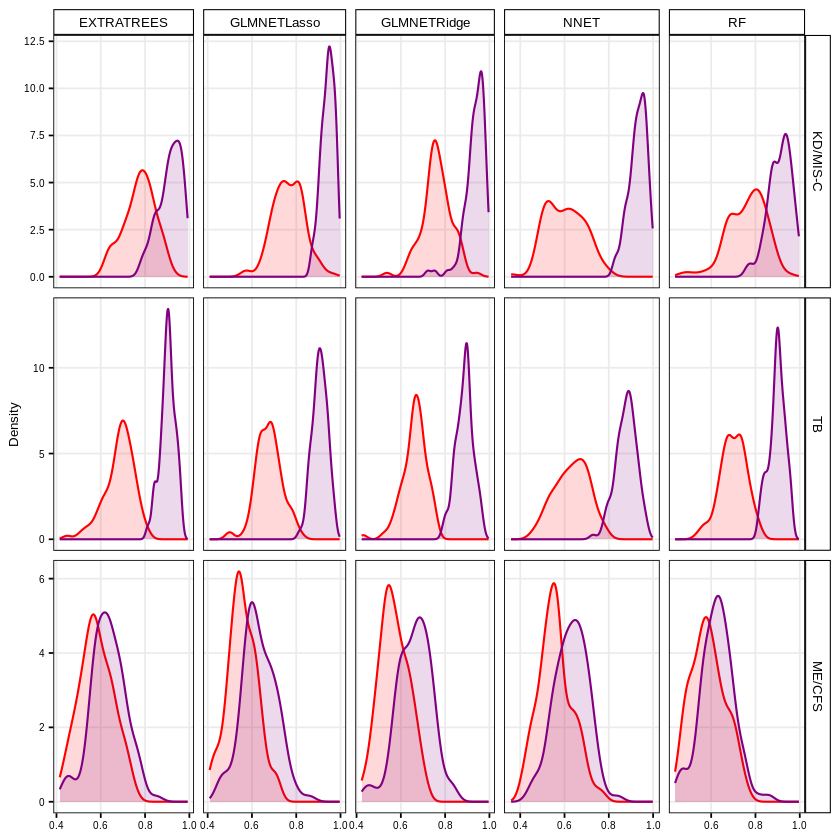

In [29]:
# desired back-to-front order
llm_order  <- c("Random",
                "DESeq",
                "Gemini 2.5 Pro",
                "ChatGPT o3",
                "Claude Opus4")

llm_colors <- c(
  "Claude Opus4"     = "#ff7613",
  "Gemini 2.5 Pro"   = "#1a73e8",
  "ChatGPT o3"       = "#10a37f",
  "Random"           = "red",
  "DESeq"            = "#800080"
)

plot_df <- auc_data %>%                           # or your own df
  filter(LLM_Model %in% llm_order) %>%           # keep only the five series
  mutate(
    LLM_Model = factor(trimws(LLM_Model), levels = llm_order),
    ML_Model  = factor(ML_Model, levels = c("EXTRATREES","GLMNETLasso",
                                            "GLMNETRidge","NNET","RF")),
    Disease   = factor(Disease,  levels = c("KD/MIS-C","TB","ME/CFS"))
  )

#pdf("/workdir/adb258/ai_paper/figures/auc_dist_new_long.pdf", width = 7, height = 4)

ggplot(plot_df, aes(x = AUC, colour = LLM_Model, fill = LLM_Model)) +
  geom_density(alpha = .15, size = 0.6) +                        # thinner curves
  facet_grid(
    Disease ~ ML_Model,
    scales = "free",
    space  = "free_x"                                            # columns widen to fit labels
  ) +
  scale_color_manual(values = llm_colors, breaks = llm_order,  name = NULL) +
  scale_fill_manual(values = llm_colors, breaks = llm_order,  guide = "none") +
  labs(x = NULL, y = "Density") +
  theme_cfrna_print() +
  theme(
    strip.background  = element_rect(colour = "black", size = 0.6, fill = NA),
    # top-of-column facet labels
    strip.text.x      = element_text(size = 8,
                                     margin = margin(t = 4, b = 4)),
    # side (row) facet labels — keep default rotation, just add padding
    strip.text.y      = element_text(size = 8,
                                     margin = margin(r = 4, l = 4)),
    panel.grid.minor  = element_blank()
  )

#dev.off()

In [30]:
tb_raw <- auc_data %>% filter(Disease == "TB")

cat("All distinct `LLM_Model` values for TB:\n")
print(sort(unique(tb_raw$LLM_Model)))

All distinct `LLM_Model` values for TB:
 [1] Random                          DESeq                          
 [3] Gemini Advanced 2.0 Flash Short Claude 3.7 Sonnet Short        
 [5] ChatGPT 4o Short                Gemini 2.5 Pro Short           
 [7] Claude Opus4 Short              ChatGPT o3 Short               
 [9] Gemini Advanced 2.0 Flash Long  Claude 3.7 Sonnet Long         
[11] ChatGPT 4o Long                 Gemini 2.5 Pro Long            
[13] Claude Opus4 Long               ChatGPT o3 Long                
14 Levels: Random DESeq ... ChatGPT o3 Long


#### Compare Model Version AUCs

In [60]:
###############################################################################
##  Helper – strip " Long" / " Short"                                         ##
###############################################################################
base_name <- function(x) sub("\\s+(Long|Short)$", "", x)

###############################################################################
##  CONFIG – factor orders & colours                                          ##
###############################################################################
disease_levels <- c("KD/MIS-C", "TB", "ME/CFS")
ml_levels      <- c("EXTRATREES","GLMNETLasso","GLMNETRidge","NNET","RF")

base_order <- c("ChatGPT 4o", "ChatGPT o3",
                "Claude 3.7 Sonnet", "Claude Opus4",
                "Gemini Advanced 2.0 Flash", "Gemini 2.5 Pro")

cols <- c(
  "ChatGPT o3"                = "#10a37f",
  "ChatGPT 4o"                = "#10a37f",
  "Claude 3.7 Sonnet"         = "#ff7613",
  "Claude Opus4"              = "#ff7613",
  "Gemini Advanced 2.0 Flash" = "#1a73e8",
  "Gemini 2.5 Pro"            = "#1a73e8"
)

###############################################################################
##  1.  Data prep  – keep only “… Long”, factorise                           ##
###############################################################################
plot_A <- auc_data %>%
  filter(str_detect(LLM_Model, "\\sLong$"), !is.na(AUC)) %>%   # after cleanup
  mutate(
    Base     = factor(base_name(LLM_Model), levels = base_order),
    ML_Model = factor(ML_Model, levels = ml_levels),
    Disease  = factor(Disease,  levels = disease_levels)
  ) %>%
  drop_na(Base)

In [76]:
###############################################################################
##  2.  AUC t-tests                                                     ##
###############################################################################
pair_list <- list(
  c("ChatGPT 4o",                "ChatGPT o3"),
  c("Claude 3.7 Sonnet",         "Claude Opus4"),
  c("Gemini Advanced 2.0 Flash", "Gemini 2.5 Pro")
)

stat_A <- purrr::map_dfr(pair_list, function(pr) {
  ggpubr::compare_means(
    AUC ~ Base,
    data     = plot_A %>% dplyr::filter(Base %in% pr),
    group.by = c("Disease", "ML_Model"),
    method   = "t.test"
  ) %>%
    dplyr::mutate(
      group1 = pr[1],
      group2 = pr[2]
    ) %>%
    dplyr::left_join(
      plot_A %>%
        dplyr::filter(Base %in% pr) %>%
        dplyr::group_by(Disease, ML_Model) %>%
        dplyr::summarise(
          n1 = sum(Base == pr[1] & !is.na(AUC)),
          n2 = sum(Base == pr[2] & !is.na(AUC)),
          df = as.numeric(stats::t.test(
            AUC[Base == pr[1]],
            AUC[Base == pr[2]]
          )$parameter),
          .groups = "drop"
        ),
      by = c("Disease", "ML_Model")
    )
}) %>%
  dplyr::mutate(
    p.adj = p.adjust(p, method = "BH"),
    p.signif = dplyr::case_when(
      p.adj < 0.0001 ~ "****",
      p.adj < 0.001  ~ "***",
      p.adj < 0.01   ~ "**",
      p.adj < 0.05   ~ "*",
      TRUE           ~ "ns"
    )
  ) %>%
  dplyr::left_join(
    plot_A %>%
      dplyr::group_by(Disease, ML_Model) %>%
      dplyr::summarise(
        y.position = max(AUC, na.rm = TRUE) + 0.07,
        .groups = "drop"
      ),
    by = c("Disease", "ML_Model")
  )

In [78]:
write.csv(stat_A, "/workdir/adb258/ai_paper/data/fig2_S2_stats_table.csv")

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”


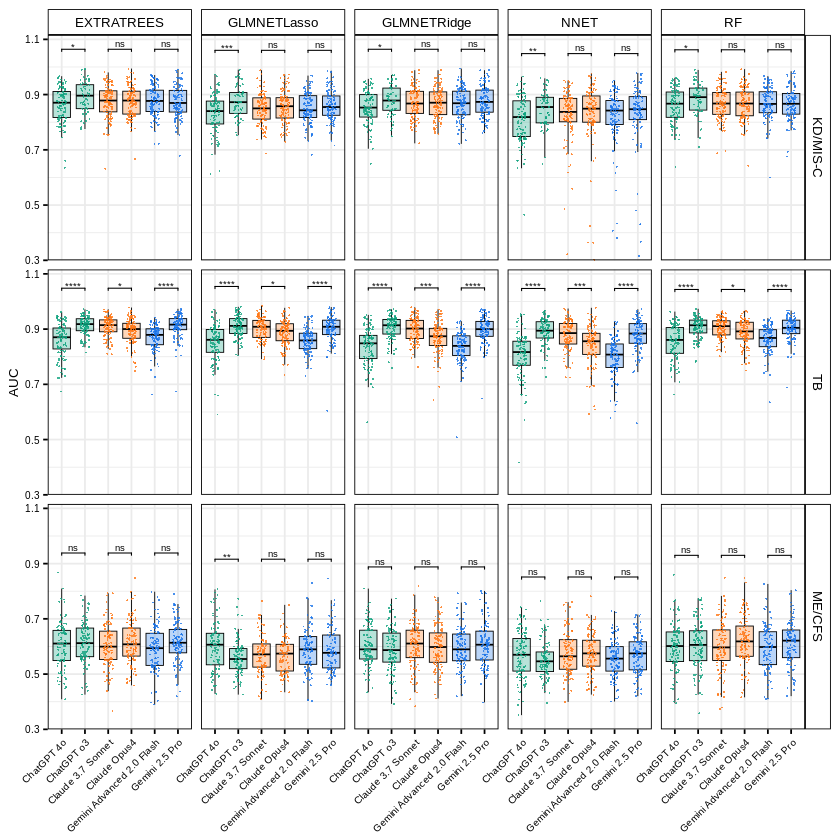

In [79]:
###############################################################################
##  3.  Plot                                                                 ##
###############################################################################
#pdf("/workdir/adb258/ai_paper/figures/auc_version_comp.pdf", width = 7, height = 6)

ggplot(plot_A, aes(x = Base, y = AUC,
                   fill = Base, colour = Base)) +
  geom_boxplot(colour = "black", lwd = .25,
               outlier.shape = NA, alpha = 0.30) +
  geom_jitter(width = .2, size = .2, alpha = .8, shape = 16) +
  stat_pvalue_manual(stat_A,
                     label       = "p.signif",
                     xmin        = "group1",
                     xmax        = "group2",
                     y.position  = "y.position",
                     size        = 2,
                     tip.length  = 0.01,
                     inherit.aes = FALSE) +
  scale_y_continuous(limits = c(0.3, 1.1),
                     expand = expansion(mult = c(0, 0.02))) +
  scale_fill_manual(values = cols) +
  scale_colour_manual(values = cols) +
  facet_grid(Disease ~ ML_Model) +
  labs(x = NULL, y = "AUC") +
  theme_cfrna_print() +
  theme(
    legend.position = "none",
    strip.text  = element_text(size = 8,
                               margin = margin(t = 4, r = 4, b = 4, l = 4)),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

#dev.off()

In [48]:
###############################################################################
##  Output exact p, t statistic, and degrees of freedom for every comparison  ##
##  shown in the figure                                                       ##
###############################################################################
stats_table_A <- purrr::map_dfr(pair_list, function(pr) {
  plot_A %>%
    dplyr::filter(Base %in% pr) %>%
    dplyr::group_by(Disease, ML_Model) %>%
    dplyr::group_modify(~{
      tt <- stats::t.test(AUC ~ Base, data = .x)

      tibble::tibble(
        group1      = pr[1],
        group2      = pr[2],
        N_1         = sum(.x$Base == pr[1]),
        N_2         = sum(.x$Base == pr[2]),
        t_statistic = unname(tt$statistic),
        df          = unname(tt$parameter),
        P_value     = tt$p.value
      )
    }) %>%
    dplyr::ungroup()
}) %>%
  dplyr::mutate(
    P_formatted = dplyr::case_when(
      P_value < 0.001 ~ "<0.001",
      TRUE ~ sprintf("%.3f", P_value)
    ),
    Significance = stats::symnum(
      P_value, corr = FALSE, na = FALSE,
      cutpoints = c(0, 0.0001, .001, .01, .05, 1),
      symbols   = c("****","***", "**", "*", "ns")
    ),
    Comparison = paste(group1, "vs", group2),
    Test = "t.test"
  ) %>%
  dplyr::select(
    Disease, ML_Model, Comparison,
    N_1, N_2, t_statistic, df, P_value,
    P_formatted, Significance, Test
  ) %>%
  dplyr::arrange(Disease, ML_Model)

In [53]:
write.csv(
  stats_table_A,
  "/workdir/adb258/ai_paper/data/figS3_stats_table.csv",
  row.names = FALSE
)

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_point()`).”


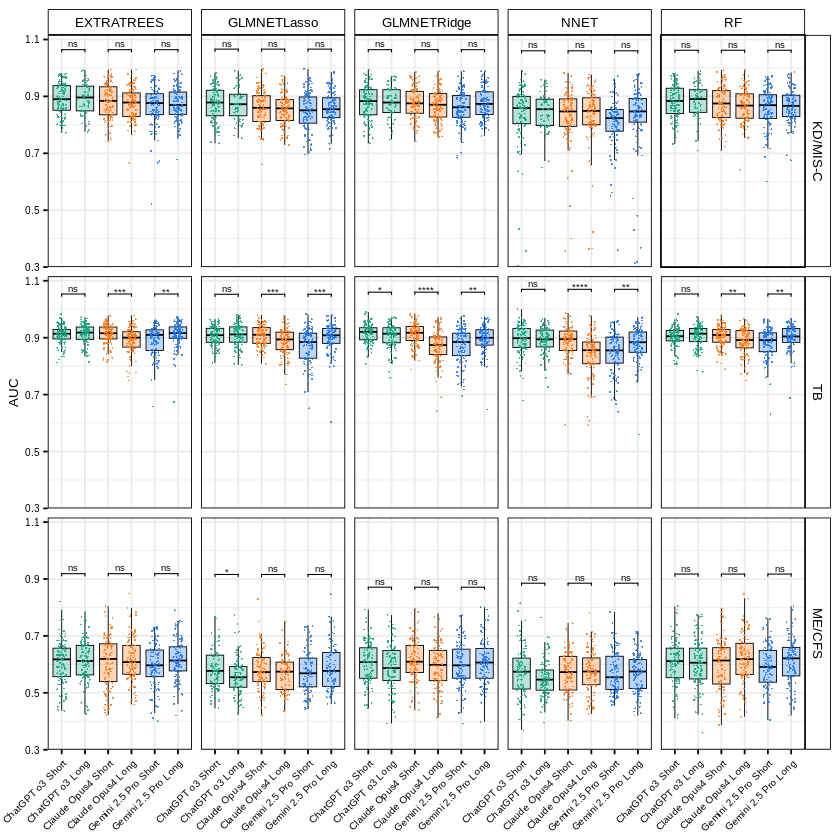

In [54]:
###############################################################################
##  CONFIG – factor orders & colours                                          ##
###############################################################################
disease_levels <- c("KD/MIS-C", "TB", "ME/CFS")
ml_levels      <- c("EXTRATREES","GLMNETLasso","GLMNETRidge","NNET","RF")

base_order <- c("ChatGPT o3 Short", "ChatGPT o3 Long",
                "Claude Opus4 Short", "Claude Opus4 Long",
                "Gemini 2.5 Pro Short", "Gemini 2.5 Pro Long")

cols <- c(
  "ChatGPT o3 Short"        = "#10a37f",
  "ChatGPT o3 Long"         = "#10a37f",
  "Claude Opus4 Short"      = "#ff7613",
  "Claude Opus4 Long"       = "#ff7613",
  "Gemini 2.5 Pro Short"    = "#1a73e8",
  "Gemini 2.5 Pro Long"     = "#1a73e8"
)

###############################################################################
##  1.  Data prep – use the full label (no stripping)                         ##
###############################################################################
plot_A <- auc_data %>%
  filter(LLM_Model %in% base_order, !is.na(AUC)) %>%   # keep only what you plot
  mutate(
    Base     = factor(LLM_Model, levels = base_order), # <-- changed
    ML_Model = factor(ML_Model, levels = ml_levels),
    Disease  = factor(Disease,  levels = disease_levels)
  )

###############################################################################
##  2.  Pair‑wise t‑tests (Short vs Long for each model)                      ##
###############################################################################
pair_list <- list(
  c("ChatGPT o3 Short",     "ChatGPT o3 Long"),
  c("Claude Opus4 Short",   "Claude Opus4 Long"),
  c("Gemini 2.5 Pro Short", "Gemini 2.5 Pro Long")
)

stat_A <- purrr::map_dfr(pair_list, function(pr) {
  ggpubr::compare_means(
    AUC ~ Base,
    data        = plot_A %>% dplyr::filter(Base %in% pr),
    group.by    = c("Disease", "ML_Model"),
    comparisons = list(pr),
    method      = "t.test",
    progress    = FALSE
  )
}) %>%
  dplyr::mutate(
    p.signif = stats::symnum(
      p, corr = FALSE, na = FALSE,
      cutpoints = c(0, 0.0001, .001, .01, .05, 1),
      symbols   = c("****", "***", "**", "*", "ns")
    )
  ) %>%
  dplyr::left_join(
    plot_A %>%
      dplyr::group_by(Disease, ML_Model) %>%
      dplyr::summarise(y.position = max(AUC, na.rm = TRUE) + 0.07,
                       .groups = "drop"),
    by = c("Disease", "ML_Model")
  )

###############################################################################
##  3.  Plot                                                                  ##
###############################################################################

#pdf("/workdir/adb258/ai_paper/figures/auc_length_comp.pdf", width = 7, height = 6)

ggplot(plot_A, aes(x = Base, y = AUC,
                   fill = Base, colour = Base)) +
  geom_boxplot(colour = "black", lwd = .25,
               outlier.shape = NA, alpha = 0.30) +
  geom_jitter(width = .2, size = .2, alpha = .8, shape = 16) +
  stat_pvalue_manual(stat_A,
                     label       = "p.signif",
                     xmin        = "group1",
                     xmax        = "group2",
                     y.position  = "y.position",
                     size        = 2,
                     tip.length  = 0.01,
                     inherit.aes = FALSE) +
  scale_y_continuous(limits = c(0.3, 1.1),
                     expand = expansion(mult = c(0, 0.02))) +
  scale_fill_manual(values = cols) +
  scale_colour_manual(values = cols) +
  facet_grid(Disease ~ ML_Model) +
  labs(x = NULL, y = "AUC") +
  theme_cfrna_print() +
  theme(
    legend.position = "none",
    strip.text  = element_text(size = 8,
                               margin = margin(t = 4, r = 4, b = 4, l = 4)),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

#dev.off()

## Extra Code

### Grab ML output

In [213]:
# =======================================================================
# 1)  CONFIGURATION ------------------------------------------------------
# =======================================================================
base_dir  <- "/workdir/hg499/Files_and_Analysis_Code"

ml_models <- c("EXTRATREES", "RF", "NNET", "GLMNETLasso", "GLMNETRidge")

allowed_llms <- c(
  
  "GPT o3 Long",            "GPT o3 Short",
  "GPT 4o Long",            "GPT 4o Short",
  "Claude Opus4 Long",      "Claude Opus4 Short",
  "Claude 3.7 Sonnet Long", "Claude 3.7 Sonnet Short",
  "Gemini 2.5 Pro Long",    "Gemini 2.5 Pro Short",
  # ── both spellings for the 2.0 Flash model ─────────────────────────
  "Gemini Advanced 2.0 Flash Long",  "Gemini Advanced 2.0 Flash Short",
  "Gemini 2.0 Flash Long",           "Gemini 2.0 Flash Short"
)
# =======================================================================
# 2)  HELPER:  Parse metadata from run directory name -------------------
# =======================================================================
parse_run_meta <- function(run_name) {
  parts <- strsplit(run_name, "_")[[1]]
  
  # ----- disease label --------------------------------------------------
  disease <- if (parts[3] %in% c("KD", "HC")) {
               paste(parts[3:4], collapse = "_")        # e.g. KD_MISC, HC_MECFS
             } else {
               parts[3]
             }
  
  # ----- raw LLM tag ----------------------------------------------------
  llm_raw <- parts[length(parts) - 1]                   # e.g. ClaudeOpus4Long
  
  # ----- variant (Long / Short) ----------------------------------------
  variant <- case_when(
    str_detect(llm_raw, regex("long$",  TRUE)) ~ "Long",
    str_detect(llm_raw, regex("short$", TRUE)) ~ "Short",
    TRUE                                       ~ NA_character_
  )
  
  # ----- base LLM name --------------------------------------------------
  base <- case_when(
    str_detect(llm_raw, regex("opus4",            TRUE)) ~ "Claude Opus4",
    str_detect(llm_raw, regex("3\\.7.*sonnet",    TRUE)) ~ "Claude 3.7 Sonnet",
    str_detect(llm_raw, regex("gpt4o",            TRUE)) ~ "GPT 4o",
    str_detect(llm_raw, regex("gpt.?o?3",         TRUE)) ~ "GPT o3",
    str_detect(llm_raw, regex("2\\.5pro",         TRUE)) ~ "Gemini 2.5 Pro",
    str_detect(llm_raw, regex("2\\.0.*flash",     TRUE)) ~ "Gemini Advanced 2.0 Flash",
    TRUE                                                 ~ NA_character_
  )
  
  # ----- combine --------------------------------------------------------
  llm <- ifelse(is.na(base) | is.na(variant),
                NA_character_,
                paste(base, variant))
  
  list(disease = disease, llm = llm)
}

# =======================================================================
# 3)  CORE EXTRACTOR -----------------------------------------------------
# =======================================================================
extract_auc <- function(run_dir) {
  run_name  <- basename(run_dir)
  meta      <- parse_run_meta(run_name)
  
  # Skip run if LLM not in allow‑list
  if (is.na(meta$llm) || !(meta$llm %in% allowed_llms)) return(tibble())
  
  seed_root <- file.path(run_dir, "output")
  seed_dirs <- list.dirs(seed_root, full.names = TRUE, recursive = FALSE)
  
  map_dfr(seed_dirs, function(sd) {
    seed_id  <- as.integer(str_remove_all(basename(sd), "\\D"))
    comp_dir <- list.dirs(sd, full.names = FALSE, recursive = FALSE)[1]
    
    map_dfr(ml_models, function(model) {
      stats_file <- file.path(
        sd, comp_dir, model,
        sprintf("%s_seed_%s_all.%s.test.txt", comp_dir, seed_id, model)
      )
      
      auc_val <- tryCatch({
                  if (!file.exists(stats_file)) {
                    NA_real_
                  } else {
                    read.delim(stats_file, header = FALSE) %>%
                    filter(V1 == "auc") %>%
                    pull(V2) %>%
                    as.numeric()
                  }
                }, error = function(e) NA_real_)
      
      tibble(
        ML_Model  = model,
        LLM_Model = meta$llm,
        Disease   = meta$disease,
        AUC       = auc_val,
        Seed      = seed_id
      )
    })
  })
}

# =======================================================================
# 4)  RUN + COLLECT ------------------------------------------------------
# =======================================================================
results_df <- list.dirs(base_dir, recursive = FALSE, full.names = TRUE) %>%
              map_dfr(extract_auc)

In [214]:
###############################################################################
##  ADD baseline files (DESeq, Random) that live in ML_output_data/          ##
###############################################################################
baseline_dir  <- file.path(base_dir, "ML_output_data")
baseline_csvs <- list.files(baseline_dir, pattern = "\\.csv$", full.names = TRUE)

read_baseline_csv <- function(file_path) {
  fname <- basename(file_path)   # e.g. ML_cfrna_TB_DESeq.csv
  
  # pull disease tag and baseline type from filename
  m <- regexec("ML_cfrna_(KD_[^_]+|MECFS|TB)_([^_]+)\\.csv", fname)
  parts <- regmatches(fname, m)[[1]]
  if (length(parts) == 0) return(data.frame())     # skip if not recognised
  
  disease_raw <- parts[2]
  llm_raw     <- parts[3]
  
  disease <- if (disease_raw == "KD_MISC") "KD/MIS-C" else disease_raw
  llm     <- if (tolower(llm_raw) == "deseq")  "DESeq"
             else if (tolower(llm_raw) == "random") "Random"
             else NA_character_
  if (is.na(llm)) return(data.frame())
  
  # ---------- read CSV (expect three columns: model, seed, auc) -----------
  df <- read.csv(file_path, stringsAsFactors = FALSE, check.names = FALSE)
  if (ncol(df) < 3) stop("Baseline CSV must have 3 columns: ", fname)

  names(df)[1:3] <- c("ML_Model", "Seed", "AUC")   # rename
  df <- df[, 1:3]                                   # keep only those
  
  data.frame(
    ML_Model  = df$ML_Model,
    LLM_Model = llm,
    Disease   = disease,
    AUC       = as.numeric(df$AUC),
    Seed      = as.integer(df$Seed),
    stringsAsFactors = FALSE
  )
}

baseline_df <- do.call(rbind, lapply(baseline_csvs, read_baseline_csv))

###############################################################################
##  COMBINE with original LLM results                                        ##
###############################################################################
results_df <- rbind(results_df, baseline_df)

# inspect or save
print(head(results_df))

# A tibble: 6 × 5
  ML_Model    LLM_Model              Disease   AUC  Seed
  <chr>       <chr>                  <chr>   <dbl> <int>
1 EXTRATREES  Claude 3.7 Sonnet Long KD_MISC 0.812     1
2 RF          Claude 3.7 Sonnet Long KD_MISC 0.821     1
3 NNET        Claude 3.7 Sonnet Long KD_MISC 0.922     1
4 GLMNETLasso Claude 3.7 Sonnet Long KD_MISC 0.904     1
5 GLMNETRidge Claude 3.7 Sonnet Long KD_MISC 0.929     1
6 EXTRATREES  Claude 3.7 Sonnet Long KD_MISC 0.814    10


In [215]:
results_df %>%
  dplyr::filter(Disease == "TB") %>%
  dplyr::distinct(LLM_Model) %>%
  dplyr::arrange(LLM_Model) %>%
  dplyr::pull()

[1] "Claude 3.7 Sonnet Long"          "Claude 3.7 Sonnet Short"        
 [3] "Claude Opus4 Long"               "Claude Opus4 Short"             
 [5] "DESeq"                           "GPT 4o Long"                    
 [7] "GPT 4o Short"                    "GPT o3 Long"                    
 [9] "GPT o3 Short"                    "Gemini 2.5 Pro Long"            
[11] "Gemini 2.5 Pro Short"            "Gemini Advanced 2.0 Flash Long" 
[13] "Gemini Advanced 2.0 Flash Short" "Random"

In [216]:
results_df <- results_df %>% 
  ## 1 ───────────────  harmonise the Disease labels  ────────────────
  mutate(
    Disease = case_when(
      Disease %in% c("KD_MISC", "KD/MISC") ~ "KD/MIS-C",
      Disease %in% c("MECFS",   "ME/CFS")  ~ "ME/CFS",
      TRUE                                 ~ Disease           # TB stays TB
    ),
    ## make it an ordered factor (KD/MIS-C → ME/CFS → TB)
    Disease = factor(Disease, levels = c("KD/MIS-C", "ME/CFS", "TB"))
  ) %>% 
  
  ## 2 ───────────────  enforce column order  ───────────────────────
  dplyr::select(ML_Model, LLM_Model, Disease, AUC, Seed) %>% 
  
  ## 3 ───────────────  sort rows exactly like auc_data  ────────────
  arrange(LLM_Model, Disease, ML_Model, Seed)

In [217]:
head(results_df)

ML_Model,LLM_Model,Disease,AUC,Seed
<chr>,<chr>,<fct>,<dbl>,<int>
EXTRATREES,Claude 3.7 Sonnet Long,KD/MIS-C,0.8117647,1
EXTRATREES,Claude 3.7 Sonnet Long,KD/MIS-C,0.8901961,2
EXTRATREES,Claude 3.7 Sonnet Long,KD/MIS-C,0.8666667,3
EXTRATREES,Claude 3.7 Sonnet Long,KD/MIS-C,0.7941176,4
EXTRATREES,Claude 3.7 Sonnet Long,KD/MIS-C,0.9137255,5
EXTRATREES,Claude 3.7 Sonnet Long,KD/MIS-C,0.8470588,6


In [218]:
results_df <- results_df %>% 
  mutate(
    Disease = factor(Disease, levels = c("KD/MIS-C", "ME/CFS", "TB"))
  ) %>% 
  dplyr::select(ML_Model, LLM_Model, Disease, AUC, Seed)

In [219]:
write.csv(results_df, "/workdir/adb258/ai_paper/data/master_auc.csv")